### Reading in the Data

In [28]:
import os
import re
import subprocess
import argparse
import glob
import pandas as pd

def merge_csv_files(base_directory, output_file):
    """
    Search through the subdirectories of 'base_directory' for CSV files,
    merge them into a single CSV file with the same header, and write the result to 'output_file'.

    Parameters:
        base_directory (str): The directory containing multiple subdirectories, each with one CSV file.
        output_file (str): The output CSV file path.
    """
    # Build search pattern: look for *.csv in all first-level subdirectories
    pattern = os.path.join(base_directory, "*", "*.csv")
    csv_files = glob.glob(pattern)

    if not csv_files:
        print("No CSV files found in any subdirectory of", base_directory)
        return

    # For logging purposes, list found files
    print("Found CSV files:")
    for file in csv_files:
        print(f" - {file}")

    # Read and store each CSV into a list of DataFrames
    df_list = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)
            df_list.append(df)
        except Exception as e:
            print(f"Error reading {file}: {e}")

    if not df_list:
        print("No CSV files could be read successfully.")
        return

    # Concatenate all DataFrames into a single DataFrame
    merged_df = pd.concat(df_list, ignore_index=True)

    # Write the merged DataFrame to the output file
    try:
        merged_df.to_csv(output_file, index=False)
        print(f"Merged CSV saved to: {output_file}")
    except Exception as e:
        print(f"Error writing merged CSV to {output_file}: {e}")
    
    return merged_df

alpha = merge_csv_files("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs_ALPHA", "/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs/AEI_ALPHA_RAW.csv")
beta = merge_csv_files("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs_BETA", "/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs/AEI_BETA_RAW.csv")
gamma = merge_csv_files("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs_GAMMA", "/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs/AEI_GAMMA_RAW.csv")

Found CSV files:
 - /tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs_ALPHA/52/EditingIndex.csv
 - /tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs_ALPHA/45/EditingIndex.csv
 - /tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs_ALPHA/41/EditingIndex.csv
 - /tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs_ALPHA/22/EditingIndex.csv
 - /tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs_ALPHA/57/EditingIndex.csv
 - /tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs_ALPHA/6/EditingIndex.csv
 - /tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs_ALPHA/37/EditingIndex.csv
 - /tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs_ALPHA/12/EditingIndex.csv
 - /tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs_ALPHA/8/Edi

In [29]:
merged = pd.concat([alpha, beta, gamma])

# Drop the specified columns: StrandDecidingMethod, Group, SamplePath
merged = merged.drop(columns=['StrandDecidingMethod', 'Group', 'SamplePath'])

# Rename the A2GEditingIndex column to AEI
merged = merged.rename(columns={'A2GEditingIndex': 'AEI'})

# Split the values in the "Sample" column into "Batch", "gene", and "sgRNA"
merged['Sample'] = merged['Sample'].str[:-1]
split_sample = merged['Sample'].str.split('_', expand=True)
merged['Batch'] = split_sample[0]
merged['Gene'] = split_sample[1]
merged['sgRNA'] = split_sample[1] + '_' + split_sample[2]


# Delete any rows where the AEI is identically 0.0
merged = merged[merged['AEI'] != 0.0]

#Reindex the DataFrame
merged = merged.reset_index(drop=True)

#Reorder the columns
merged = merged[['Batch', 'Gene', 'sgRNA', 'AEI', 'A2CEditingIndex', 'A2TEditingIndex', 'C2AEditingIndex', 'C2GEditingIndex', 'C2TEditingIndex']]

#Save the cleaned DataFrame to a new CSV file
merged.to_csv("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs/AEI_MERGED_RAW.csv", index=False)

### Raw Data Visualization

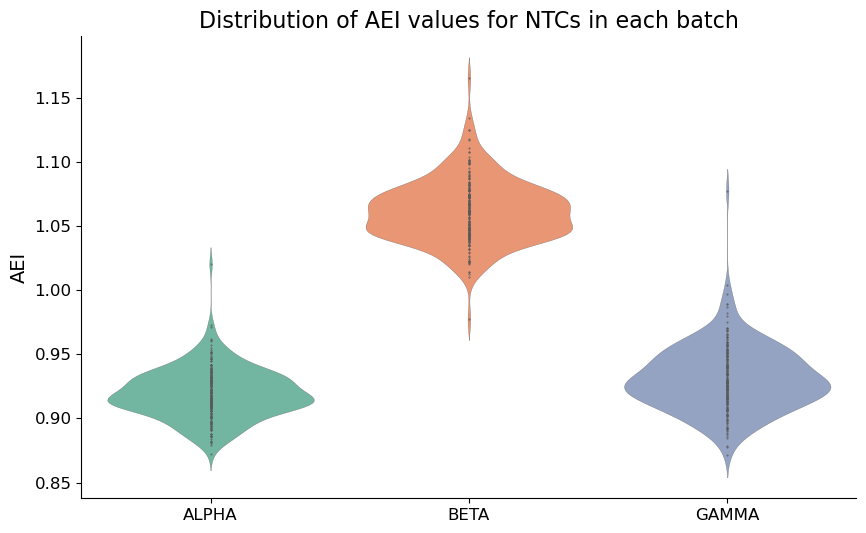

In [30]:
# Visualize the distribution of AEI values for the NTCs in each batch via violin plot
import seaborn as sns
import matplotlib.pyplot as plt\

NTCs = merged[merged['Gene'] == 'Non-Targeting']
plt.figure(figsize=(10, 6))
sns.violinplot(x='Batch', y='AEI', data=NTCs, inner='point', palette='Set2', linewidth=.2, hue='Batch')  # Set x to 'Batch' for proper labeling
plt.title('Distribution of AEI values for NTCs in each batch', fontsize=16)  # Increased font size
plt.ylabel('AEI', fontsize=14)  # Increased font size
plt.tick_params(axis='both', which='major', labelsize=12)  # Thicker axes
plt.xticks(rotation=0)  # Rotate batch names for better visibility
plt.gca().set_xlabel('')  # Turn off the x label
plt.gca().spines['top'].set_visible(False)  # Remove the top spine
plt.gca().spines['right'].set_visible(False)  # Remove the right spine
plt.show()

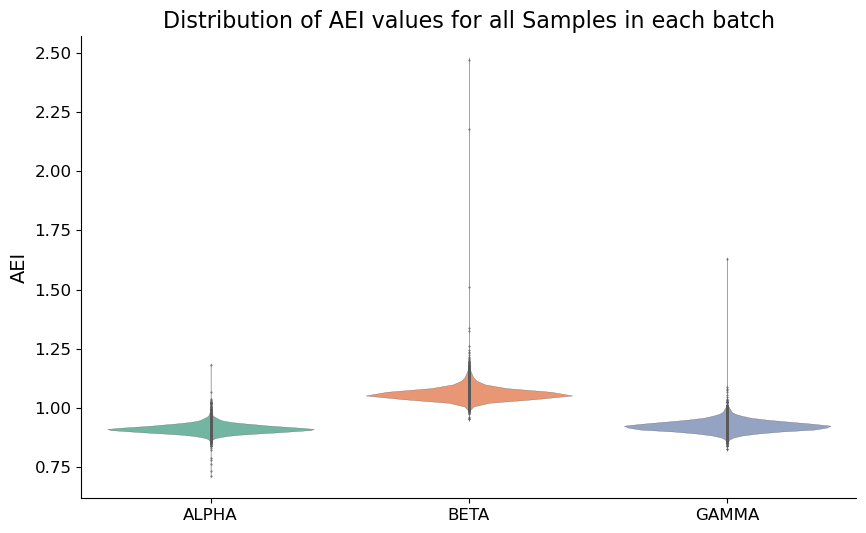

In [31]:
# Visualize the distribution of AEI values for the NTCs in each batch via violin plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.violinplot(x='Batch', y='AEI', data=merged, inner='point', palette='Set2', linewidth=.2, hue='Batch')  # Set x to 'Batch' for proper labeling
plt.title('Distribution of AEI values for all Samples in each batch', fontsize=16)  # Increased font size
plt.ylabel('AEI', fontsize=14)  # Increased font size
plt.tick_params(axis='both', which='major', labelsize=12)  # Thicker axes
plt.xticks(rotation=0)  # Rotate batch names for better visibility
plt.gca().set_xlabel('')  # Turn off the x label
plt.gca().spines['top'].set_visible(False)  # Remove the top spine
plt.gca().spines['right'].set_visible(False)  # Remove the right spine
plt.show()

In [68]:
import os
import pysam
from tqdm import tqdm  # Import tqdm for progress bar

bam_files = os.listdir("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/merged_bam_files")
batch = {"ALPHA": 0, "BETA": 0, "GAMMA": 0}

# Use tqdm to create a progress bar for the file processing
for file in tqdm(bam_files, desc="Processing BAM files", unit="file"):
    if file.endswith(".bam"):
        filepath = os.path.join("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/merged_bam_files", file)
        batch_name = file.split("_")[0]
        total_reads = sum(int(line.split()[2]) for line in pysam.idxstats(filepath).splitlines())
        batch[batch_name] += total_reads

for key, value in batch.items():
    print(f"Batch {key}: Total reads = {value:,}")

Processing BAM files: 100%|██████████| 48102/48102 [18:45<00:00, 42.73file/s]

Batch ALPHA: Total reads = 11,270,803,946
Batch BETA: Total reads = 10,614,115,656
Batch GAMMA: Total reads = 9,833,467,418


### Filtering out duplicated genes

In [53]:
# Print out the genes, the list of associated batches, and the number of sgRNAs of that gene in each batch for duplicated genes only
duplicate_genes = merged.groupby("Gene")["Batch"].nunique()
duplicate_genes = duplicate_genes[duplicate_genes > 1].index.unique()

gene_batches = merged[merged["Gene"].isin(duplicate_genes)].groupby("Gene").agg(
    Batch=('Batch', lambda x: list(x.unique())),
    sgRNA_Count=('sgRNA', 'count'),
    sgRNA_count_Alpha=('sgRNA', lambda x: x[merged['Batch'] == 'ALPHA'].count()),
    sgRNA_count_Beta=('sgRNA', lambda x: x[merged['Batch'] == 'BETA'].count()),
    sgRNA_count_Gamma=('sgRNA', lambda x: x[merged['Batch'] == 'GAMMA'].count())
).reset_index()

gene_batches

,Gene,Batch,sgRNA_Count,sgRNA_count_Alpha,sgRNA_count_Beta,sgRNA_count_Gamma
0,AZI2,"[ALPHA, GAMMA]",6,3,0,3
1,CCZ1,"[BETA, GAMMA]",5,0,3,2
2,CTAGE4,"[BETA, GAMMA]",4,0,2,2
3,ERV3-1,"[ALPHA, GAMMA]",6,3,0,3
4,F8A1,"[BETA, GAMMA]",4,0,2,2
5,FAM72B,"[BETA, GAMMA]",4,0,2,2
6,KIAA1586,"[ALPHA, BETA]",5,2,3,0
7,KYAT3,"[ALPHA, BETA]",6,3,3,0
8,NPIPA8,"[BETA, GAMMA]",4,0,2,2
9,Non-Targeting,"[ALPHA, BETA, GAMMA]",707,236,236,235


In [54]:
# For every gene (except 'Non-Targeting') choose the batch with the most sgRNAs
print("Gene batch assignment (choosing batch with the most sgRNAs):")
for idx, row in gene_batches.iterrows():
    gene = row["Gene"]
    if gene != "Non-Targeting":
        # Extract sgRNA counts per batch. Adjust column names as needed.
        count_alpha = row.get("sgRNA_count_Alpha", 0)
        count_beta = row.get("sgRNA_count_Beta", 0)
        count_gamma = row.get("sgRNA_count_Gamma", 0)
        
        # Create a dictionary of counts per batch.
        batch_counts = {
            "ALPHA": count_alpha,
            "BETA": count_beta,
            "GAMMA": count_gamma
        }
        
        # Determine the batch with the highest number of sgRNAs.
        best_batch = max(batch_counts, key=batch_counts.get)
        print(f"Gene: {gene}, Batch with most sgRNAs: {best_batch} (Counts: {batch_counts})")

Gene batch assignment (choosing batch with the most sgRNAs):
Gene: AZI2, Batch with most sgRNAs: ALPHA (Counts: {'ALPHA': 3, 'BETA': 0, 'GAMMA': 3})
Gene: CCZ1, Batch with most sgRNAs: BETA (Counts: {'ALPHA': 0, 'BETA': 3, 'GAMMA': 2})
Gene: CTAGE4, Batch with most sgRNAs: BETA (Counts: {'ALPHA': 0, 'BETA': 2, 'GAMMA': 2})
Gene: ERV3-1, Batch with most sgRNAs: ALPHA (Counts: {'ALPHA': 3, 'BETA': 0, 'GAMMA': 3})
Gene: F8A1, Batch with most sgRNAs: BETA (Counts: {'ALPHA': 0, 'BETA': 2, 'GAMMA': 2})
Gene: FAM72B, Batch with most sgRNAs: BETA (Counts: {'ALPHA': 0, 'BETA': 2, 'GAMMA': 2})
Gene: KIAA1586, Batch with most sgRNAs: BETA (Counts: {'ALPHA': 2, 'BETA': 3, 'GAMMA': 0})
Gene: KYAT3, Batch with most sgRNAs: ALPHA (Counts: {'ALPHA': 3, 'BETA': 3, 'GAMMA': 0})
Gene: NPIPA8, Batch with most sgRNAs: BETA (Counts: {'ALPHA': 0, 'BETA': 2, 'GAMMA': 2})
Gene: PCDHB13, Batch with most sgRNAs: BETA (Counts: {'ALPHA': 0, 'BETA': 3, 'GAMMA': 2})
Gene: SLX1A, Batch with most sgRNAs: ALPHA (Counts

In [55]:
# ------------------------------------------------------------------------------
# Step 1: Compute the number of unique sgRNAs per gene for each Batch.
gene_batch_counts = merged.groupby(['Gene', 'Batch'])['sgRNA'] \
    .nunique() \
    .reset_index(name='sgRNA_count')

# ------------------------------------------------------------------------------
# Step 2: For every gene (except "Non-Targeting"), choose the batch with the most sgRNAs.
gene_best_batch = {}
for gene in gene_batch_counts['Gene'].unique():
    if gene == 'Non-Targeting':
        continue  # Keep all Non-Targeting rows
    subset = gene_batch_counts[gene_batch_counts['Gene'] == gene]
    best_idx = subset['sgRNA_count'].idxmax()
    best_batch = subset.loc[best_idx, 'Batch']
    gene_best_batch[gene] = best_batch

# ------------------------------------------------------------------------------
# Step 3: Drop rows from merged_filtered that are not in the best batch for their gene.
def row_kept(row):
    # Always keep Non-Targeting rows.
    if row['Gene'] == 'Non-Targeting':
        return True
    # Otherwise, only keep the row if its Batch matches the best batch computed earlier.
    return row['Batch'] == gene_best_batch.get(row['Gene'], row['Batch'])

merged = merged[merged.apply(row_kept, axis=1)].reset_index(drop=True)

### Z-score Normalization

In [96]:
### NTC Cleaning
# Filter Non-Targeting sgRNA for each batch
ntc_filtered = merged[merged['sgRNA'].str.contains('Non-Targeting')].copy()

# Compute the z-score for each sgRNA in the NTCs per batch
ntc_filtered['z_score'] = ntc_filtered.groupby('Batch')['AEI'].transform(lambda x: (x - x.mean()) / x.std())

# Calculate bounds for the central 80% per batch using groupby transform. Here, we are taking the sgRNA that are in the central 80% of the distribution for each batch, and then we intersect the sgRNAs across all batches, keeping only the sgRNAs that are shared across all batches.
ntc_filtered['lower_bound'] = ntc_filtered.groupby('Batch')['z_score'].transform(lambda x: x.quantile(0.10))
ntc_filtered['upper_bound'] = ntc_filtered.groupby('Batch')['z_score'].transform(lambda x: x.quantile(0.90))

# Select only the rows where z_score is between lower_bound and upper_bound
ntc_in_central_80 = ntc_filtered[
    (ntc_filtered['z_score'] >= ntc_filtered['lower_bound']) & 
    (ntc_filtered['z_score'] <= ntc_filtered['upper_bound'])
]

# Optionally, drop the intermediate lower_bound and upper_bound columns
ntc_in_central_80 = ntc_in_central_80.drop(columns=['lower_bound', 'upper_bound'])

# Determine qualifying sgRNAs per batch
qualifying_sgRNAs = ntc_in_central_80.groupby("Batch")["sgRNA"].unique()

# Compute the intersection across all three batches
common_sgRNAs = set(qualifying_sgRNAs.iloc[0]).intersection(*qualifying_sgRNAs.iloc[1:])

# Filter to keep only those sgRNAs present in all batches
ntc_final = ntc_in_central_80[ntc_in_central_80['sgRNA'].isin(common_sgRNAs)]
print(f'Number of NTC sgRNA in the central 80% present in all batches: {len(common_sgRNAs)}')

# Filter for all sgRNAs that are not NTCs or in the central 80% of the distribution for each batch
merged_filtered = merged.copy()
merged_filtered = merged_filtered[merged_filtered['sgRNA'].isin(ntc_final['sgRNA']) | ~merged_filtered['sgRNA'].str.contains('Non-Targeting')]

# Recompute the Z-score based on the filtered sgRNA
ntc_stats = merged_filtered[merged_filtered['Gene'] == 'Non-Targeting']\
    .groupby('Batch')['AEI']\
    .agg(['mean', 'std']).reset_index()
ntc_stats.columns = ['Batch', 'ntc_mean', 'ntc_std']

# Merge the NTC statistics back into the main dataframe
merged_filtered = merged_filtered.merge(ntc_stats, on='Batch', how='left')

# Calculate z-score relative to batch's NTCs
merged_filtered['z_score'] = (merged_filtered['AEI'] - merged_filtered['ntc_mean']) / merged_filtered['ntc_std']

# Optional: Clean up intermediate columns
merged_filtered = merged_filtered.drop(columns=['ntc_mean', 'ntc_std'])

# Save the filtered DataFrame to a new CSV file
merged_filtered.to_csv("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs/AEI_MERGED_FILTERED.csv", index=False)
merged_filtered

Number of NTC sgRNA in the central 80% present in all batches: 124


,Batch,Gene,sgRNA,AEI,A2CEditingIndex,A2TEditingIndex,C2AEditingIndex,C2GEditingIndex,C2TEditingIndex,z_score
0,ALPHA,THAP5,THAP5_2,0.931499,0.067799,0.106960,0.084728,0.062715,0.269004,1.080802
1,ALPHA,THAP2,THAP2_1,0.927552,0.062790,0.093652,0.083528,0.058487,0.242971,0.735525
2,ALPHA,THUMPD3,THUMPD3_3,0.898194,0.061698,0.093458,0.080792,0.055281,0.242378,-1.832857
3,ALPHA,TIGD1,TIGD1_3,0.951302,0.066775,0.107478,0.085009,0.060809,0.265499,2.813258
4,ALPHA,TIGD2,TIGD2_3,0.958488,0.065168,0.098542,0.082441,0.061141,0.261768,3.441855
...,...,...,...,...,...,...,...,...,...,...
23597,GAMMA,IMPA1,IMPA1_2,0.949961,0.063105,0.084459,0.119348,0.060330,0.239265,1.351217
23598,GAMMA,INPP4A,INPP4A_3,0.889558,0.060888,0.090859,0.129566,0.061108,0.246638,-2.590441
23599,GAMMA,IRAK4,IRAK4_2,0.926444,0.063853,0.090503,0.135003,0.058794,0.251844,-0.183383
23600,GAMMA,INSR,INSR_2,0.921260,0.065404,0.095419,0.128071,0.064569,0.256826,-0.521691


### Statistical Testing

In [97]:
import pandas as pd
merged_filtered = pd.read_csv("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs/AEI_MERGED_FILTERED.csv")

In [65]:
import numpy as np
import pandas as pd
from tqdm.contrib.concurrent import process_map
from scipy.stats import permutation_test
from statsmodels.stats.multitest import multipletests

def run_permutation_test(task, num_permutations=100000):
    # Unpack the task tuple
    batch, gene, gene_values, ntc_values = task
    gene_values = np.array(gene_values)
    ntc_values = np.array(ntc_values)
    
    # Define the test statistic as the difference in means (gene - control)
    def statistic(x, y):
        return np.mean(x) - np.mean(y)
    
    # Run the permutation test
    res = permutation_test(
        (gene_values, ntc_values),
        statistic,
        permutation_type='independent',
        alternative='two-sided',
        n_resamples=num_permutations,
        vectorized=False
    )
    
    return {
        'Batch': batch,
        'Gene': gene,
        'observed_stat': res.statistic,
        'p_value': res.pvalue,
        'num_permutations': num_permutations
    }

# Build a list of tasks for each batch and gene (excluding 'Non-Targeting')
tasks = []
for batch in merged_filtered['Batch'].unique():
    batch_data = merged_filtered[merged_filtered['Batch'] == batch]
    ntc_series = batch_data[batch_data['Gene'] == 'Non-Targeting']['AEI']
    if ntc_series.empty:
        continue
    ntc_list = ntc_series.tolist()
    
    for gene in batch_data['Gene'].unique():
        if gene == 'Non-Targeting':
            continue
        gene_series = batch_data[batch_data['Gene'] == gene]['AEI']
        if gene_series.empty:
            continue
        gene_list = gene_series.tolist()
        tasks.append((batch, gene, gene_list, ntc_list))

# Run the permutation tests in parallel
results = process_map(run_permutation_test, tasks, desc="Running permutation tests", chunksize=1)

# Convert results to a DataFrame
permutation_test_df = pd.DataFrame(results)

# Apply Benjamini-Hochberg correction
permutation_test_df['p_value_corrected'] = multipletests(permutation_test_df['p_value'], method='fdr_bh')[1]
permutation_test_df

Running permutation tests:   0%|          | 0/8746 [00:00<?, ?it/s]

,Batch,Gene,observed_stat,p_value,num_permutations,p_value_corrected
0,ALPHA,THAP5,0.007668,0.268737,100000,0.551602
1,ALPHA,THAP2,0.004722,0.492035,100000,0.744181
2,ALPHA,THUMPD3,-0.014741,0.023420,100000,0.126829
3,ALPHA,TIGD1,0.011380,0.194540,100000,0.463609
4,ALPHA,TIGD2,0.021495,0.003420,100000,0.039048
...,...,...,...,...,...,...
8741,GAMMA,INKA1,-0.016023,0.141714,100000,0.385636
8742,GAMMA,INSYN1,-0.020165,0.055873,100000,0.218544
8743,GAMMA,IMPA2,0.013712,0.229841,100000,0.506091
8744,GAMMA,INPP5K,-0.008422,0.476698,100000,0.733756


In [98]:
# 1. Compute gene-level average values using groupby with transform.
merged_filtered["Gene Average AEI"] = merged_filtered.groupby(['Batch', 'Gene'])['AEI'].transform('mean')
merged_filtered["Gene Average Z-Score"] = merged_filtered.groupby(['Batch', 'Gene'])['z_score'].transform('mean')

# 2. Compute the number of unique sgRNAs per gene.
gene_sgRNA_count = merged_filtered.groupby(['Batch', 'Gene'])['sgRNA'].nunique().reset_index(name='Gene Number of sgRNAs')

# Merge the unique sgRNA count into merged_filtered.
merged_filtered = merged_filtered.merge(
    gene_sgRNA_count,
    on=["Batch", "Gene"],
    how='left'
)

# 3. Merge in the permutation test results from permutation_test_df.
# Use suffixes to avoid conflicts if permutation_test_df contains columns such as 'AEI' or 'z_score'.
merged_filtered = merged_filtered.merge(
    permutation_test_df,
    on=["Batch", "Gene"],
    how='left',
    suffixes=('', '_gene')
)

# Check that every sgRNA now has the same Average AEI and Average Z-Score for its Gene.
merged_filtered.sort_values('Gene Average Z-Score', ascending=True)
display(merged_filtered.head())

#Set the Non-Targeting default values
merged_filtered.loc[merged_filtered['Gene'] == 'Non-Targeting', 'p_value_corrected'] = 1
merged_filtered.loc[merged_filtered['Gene'] == 'Non-Targeting', 'p_value'] = 1
merged_filtered.loc[merged_filtered['Gene'] == 'Non-Targeting', 'observed_stat'] = 0
merged_filtered.loc[merged_filtered['Gene'] == 'Non-Targeting', 'num_permutations'] = 0

def reduce_to_gene_level(merged_filtered):
    reduced_df = merged_filtered.drop(columns=['sgRNA', 'AEI', 'A2CEditingIndex', 'A2TEditingIndex', 'C2AEditingIndex', 'C2GEditingIndex', 'C2TEditingIndex', 'z_score'])
    reduced_df = reduced_df.drop_duplicates(subset=['Batch', 'Gene'])
    return reduced_df

merged_filtered_gene_level = reduce_to_gene_level(merged_filtered)
display(merged_filtered_gene_level.head())
merged_filtered.to_csv("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs/AEI_MERGED_FILTERED.csv", index=False)
merged_filtered_gene_level.to_csv("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs/AEI_MERGED_FILTERED_GENE_LEVEL.csv", index=False)

,Batch,Gene,sgRNA,AEI,A2CEditingIndex,A2TEditingIndex,C2AEditingIndex,C2GEditingIndex,C2TEditingIndex,z_score,Gene Average AEI,Gene Average Z-Score,Gene Number of sgRNAs,observed_stat,p_value,num_permutations,p_value_corrected
0,ALPHA,THAP5,THAP5_2,0.931499,0.067799,0.106960,0.084728,0.062715,0.269004,1.080802,0.926813,0.670846,3,0.007668,0.268737,100000.0,0.551602
1,ALPHA,THAP2,THAP2_1,0.927552,0.062790,0.093652,0.083528,0.058487,0.242971,0.735525,0.923867,0.413131,3,0.004722,0.492035,100000.0,0.744181
2,ALPHA,THUMPD3,THUMPD3_3,0.898194,0.061698,0.093458,0.080792,0.055281,0.242378,-1.832857,0.904404,-1.289575,3,-0.014741,0.023420,100000.0,0.126829
3,ALPHA,TIGD1,TIGD1_3,0.951302,0.066775,0.107478,0.085009,0.060809,0.265499,2.813258,0.930525,0.995576,2,0.011380,0.194540,100000.0,0.463609
4,ALPHA,TIGD2,TIGD2_3,0.958488,0.065168,0.098542,0.082441,0.061141,0.261768,3.441855,0.940640,1.880464,3,0.021495,0.003420,100000.0,0.039048


,Batch,Gene,Gene Average AEI,Gene Average Z-Score,Gene Number of sgRNAs,observed_stat,p_value,num_permutations,p_value_corrected
0,ALPHA,THAP5,0.926813,0.670846,3,0.007668,0.268737,100000.0,0.551602
1,ALPHA,THAP2,0.923867,0.413131,3,0.004722,0.492035,100000.0,0.744181
2,ALPHA,THUMPD3,0.904404,-1.289575,3,-0.014741,0.023420,100000.0,0.126829
3,ALPHA,TIGD1,0.930525,0.995576,2,0.011380,0.194540,100000.0,0.463609
4,ALPHA,TIGD2,0.940640,1.880464,3,0.021495,0.003420,100000.0,0.039048


In [1]:
import pandas as pd
merged_filtered = pd.read_csv("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs/AEI_MERGED_FILTERED.csv")
merged_filtered_gene_level = pd.read_csv("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs/AEI_MERGED_FILTERED_GENE_LEVEL.csv")

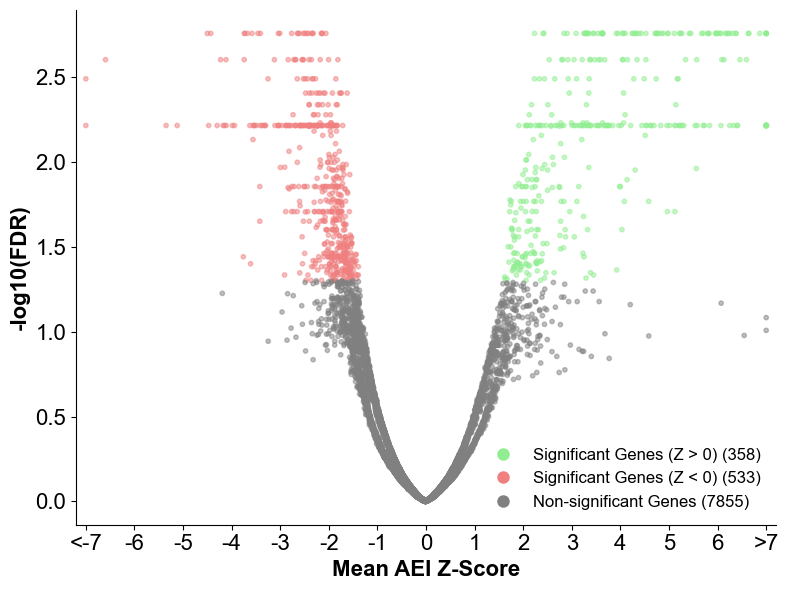

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'

def plot_gene_significance(merged_filtered_gene_level):
    fig, ax = plt.subplots(figsize=(8, 6))

    #Remove the Non-Targeting row
    sorted_genes = merged_filtered_gene_level[merged_filtered_gene_level['Gene'] != 'Non-Targeting'].sort_values('p_value_corrected')

    # Define colors based on significance
    colors = np.where(
        (sorted_genes['p_value_corrected'] < 0.05) & (sorted_genes['Gene Average Z-Score'] > 0), 'lightgreen',
        np.where((sorted_genes['p_value_corrected'] < 0.05) & (sorted_genes['Gene Average Z-Score'] < 0), 'lightcoral', 'gray'))

    # Increase marker size for visibility
    marker_size = 10

    # Clip mean_z_score values to be within the limits
    clipped_z_scores = np.clip(sorted_genes['Gene Average Z-Score'], -7, 7)

    # Plot data using -log10 of p-value
    scatter = ax.scatter(clipped_z_scores, -np.log10(sorted_genes['p_value_corrected']), alpha=0.5, s=marker_size, color=colors)

    # Set x-limits and customize x-ticks
    ax.set_xlim(-7.2, 7.2)
    ax.set_xticks(np.arange(-7, 8))
    ax.set_xticklabels(['<-7'] + [str(i) for i in range(-6, 7)] + ['>7'])
    ax.tick_params(axis='both', labelsize=16)  # Set y-ticks fontsize to 12
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Labeling the axes
    ax.set_ylabel('-log10(FDR)', fontsize=16, fontweight='bold')
    ax.set_xlabel('Mean AEI Z-Score', fontsize=16, fontweight='bold')

    # Improve tick readability
    ax.tick_params(axis='both', labelsize=16)  # Increased tick label size

    # Add label for significant genes
    # Add a legend for the color coding
    num_significant_positive = ((sorted_genes['p_value_corrected'] < 0.05) & (sorted_genes['Gene Average Z-Score'] > 0)).sum()
    num_significant_negative = ((sorted_genes['p_value_corrected'] < 0.05) & (sorted_genes['Gene Average Z-Score'] < 0)).sum()
    ax.legend(handles=[
        plt.Line2D([0], [0], marker='o', color='w', label='Significant Genes (Z > 0) ({})'.format(num_significant_positive), 
                   markerfacecolor='lightgreen', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', label='Significant Genes (Z < 0) ({})'.format(num_significant_negative), 
                   markerfacecolor='lightcoral', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', label='Non-significant Genes ({})'.format(len(sorted_genes) - num_significant_positive - num_significant_negative), 
                   markerfacecolor='gray', markersize=10)
    ], loc='lower right', fontsize=12, frameon=False)

    plt.tight_layout()  # Ensure everything fits without overlapping
    return fig

fig = plot_gene_significance(merged_filtered_gene_level)
fig.savefig("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs/Figures/AEI_Z_Score_vs_FDR.svg", bbox_inches='tight')  # Save with tight layout

In [3]:
def get_significant_genes(merged_filtered_gene_level):
    significant_positive_genes = merged_filtered_gene_level[(merged_filtered_gene_level['p_value_corrected'] < 0.05) & (merged_filtered_gene_level['Gene Average Z-Score'] > 0)]['Gene'].unique()
    significant_negative_genes = merged_filtered_gene_level[(merged_filtered_gene_level['p_value_corrected'] < 0.05) & (merged_filtered_gene_level['Gene Average Z-Score'] < 0)]['Gene'].unique()
    return significant_positive_genes, significant_negative_genes

significant_positive_genes, significant_negative_genes = get_significant_genes(merged_filtered_gene_level)

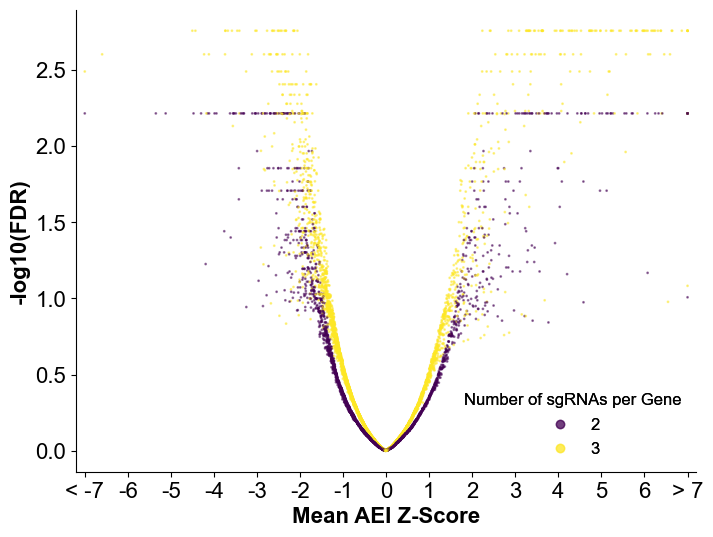

In [4]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.family'] = 'Arial'

def plot_gene_significance(merged_filtered_gene_level):
    fig, ax = plt.subplots(figsize=(8, 6))

        #Remove the Non-Targeting row
    sorted_genes = merged_filtered_gene_level[merged_filtered_gene_level['Gene'] != 'Non-Targeting'].sort_values('p_value_corrected')

    # Increase marker size for visibility
    marker_size = 1

    # Clip mean_z_score values to be within the limits
    clipped_z_scores = np.clip(sorted_genes['Gene Average Z-Score'], -7, 7)

    # Plot data using -log10 of p-value
    scatter = ax.scatter(clipped_z_scores, -np.log10(sorted_genes['p_value_corrected']), alpha=0.5, s=marker_size, c=sorted_genes['Gene Number of sgRNAs'], cmap='viridis')

    # Set x-limits and customize x-ticks
    ax.set_xlim(-7.2, 7.2)
    ax.set_xticks(np.arange(-7, 8))
    ax.set_xticklabels(['< -7'] + [str(i) for i in range(-6, 7)] + ['> 7'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


    # Labeling the axes
    ax.set_ylabel('-log10(FDR)', fontsize=16, fontweight='bold')
    ax.set_xlabel('Mean AEI Z-Score', fontsize=16, fontweight='bold')

    # Improve tick readability
    ax.tick_params(axis='both', labelsize=16)  # Increased tick label size

    # Add label for significant genes
    # Add a legend for the color coding
    # Create a legend for the number of sgRNAs
    legend1 = ax.legend(*scatter.legend_elements(), title="Number of sgRNAs per Gene", loc='lower right', frameon=False, fontsize=12, title_fontsize=12)
    ax.add_artist(legend1)
    return fig

fig = plot_gene_significance(merged_filtered_gene_level)
fig.savefig("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs/Figures/AEI_Z_Score_vs_FDR_Number_of_sgRNAs.svg", bbox_inches='tight')

### Plotting

In [5]:
significant_genes = merged_filtered[(merged_filtered['p_value_corrected'] < 0.05) | (merged_filtered['Gene'] == 'Non-Targeting')]

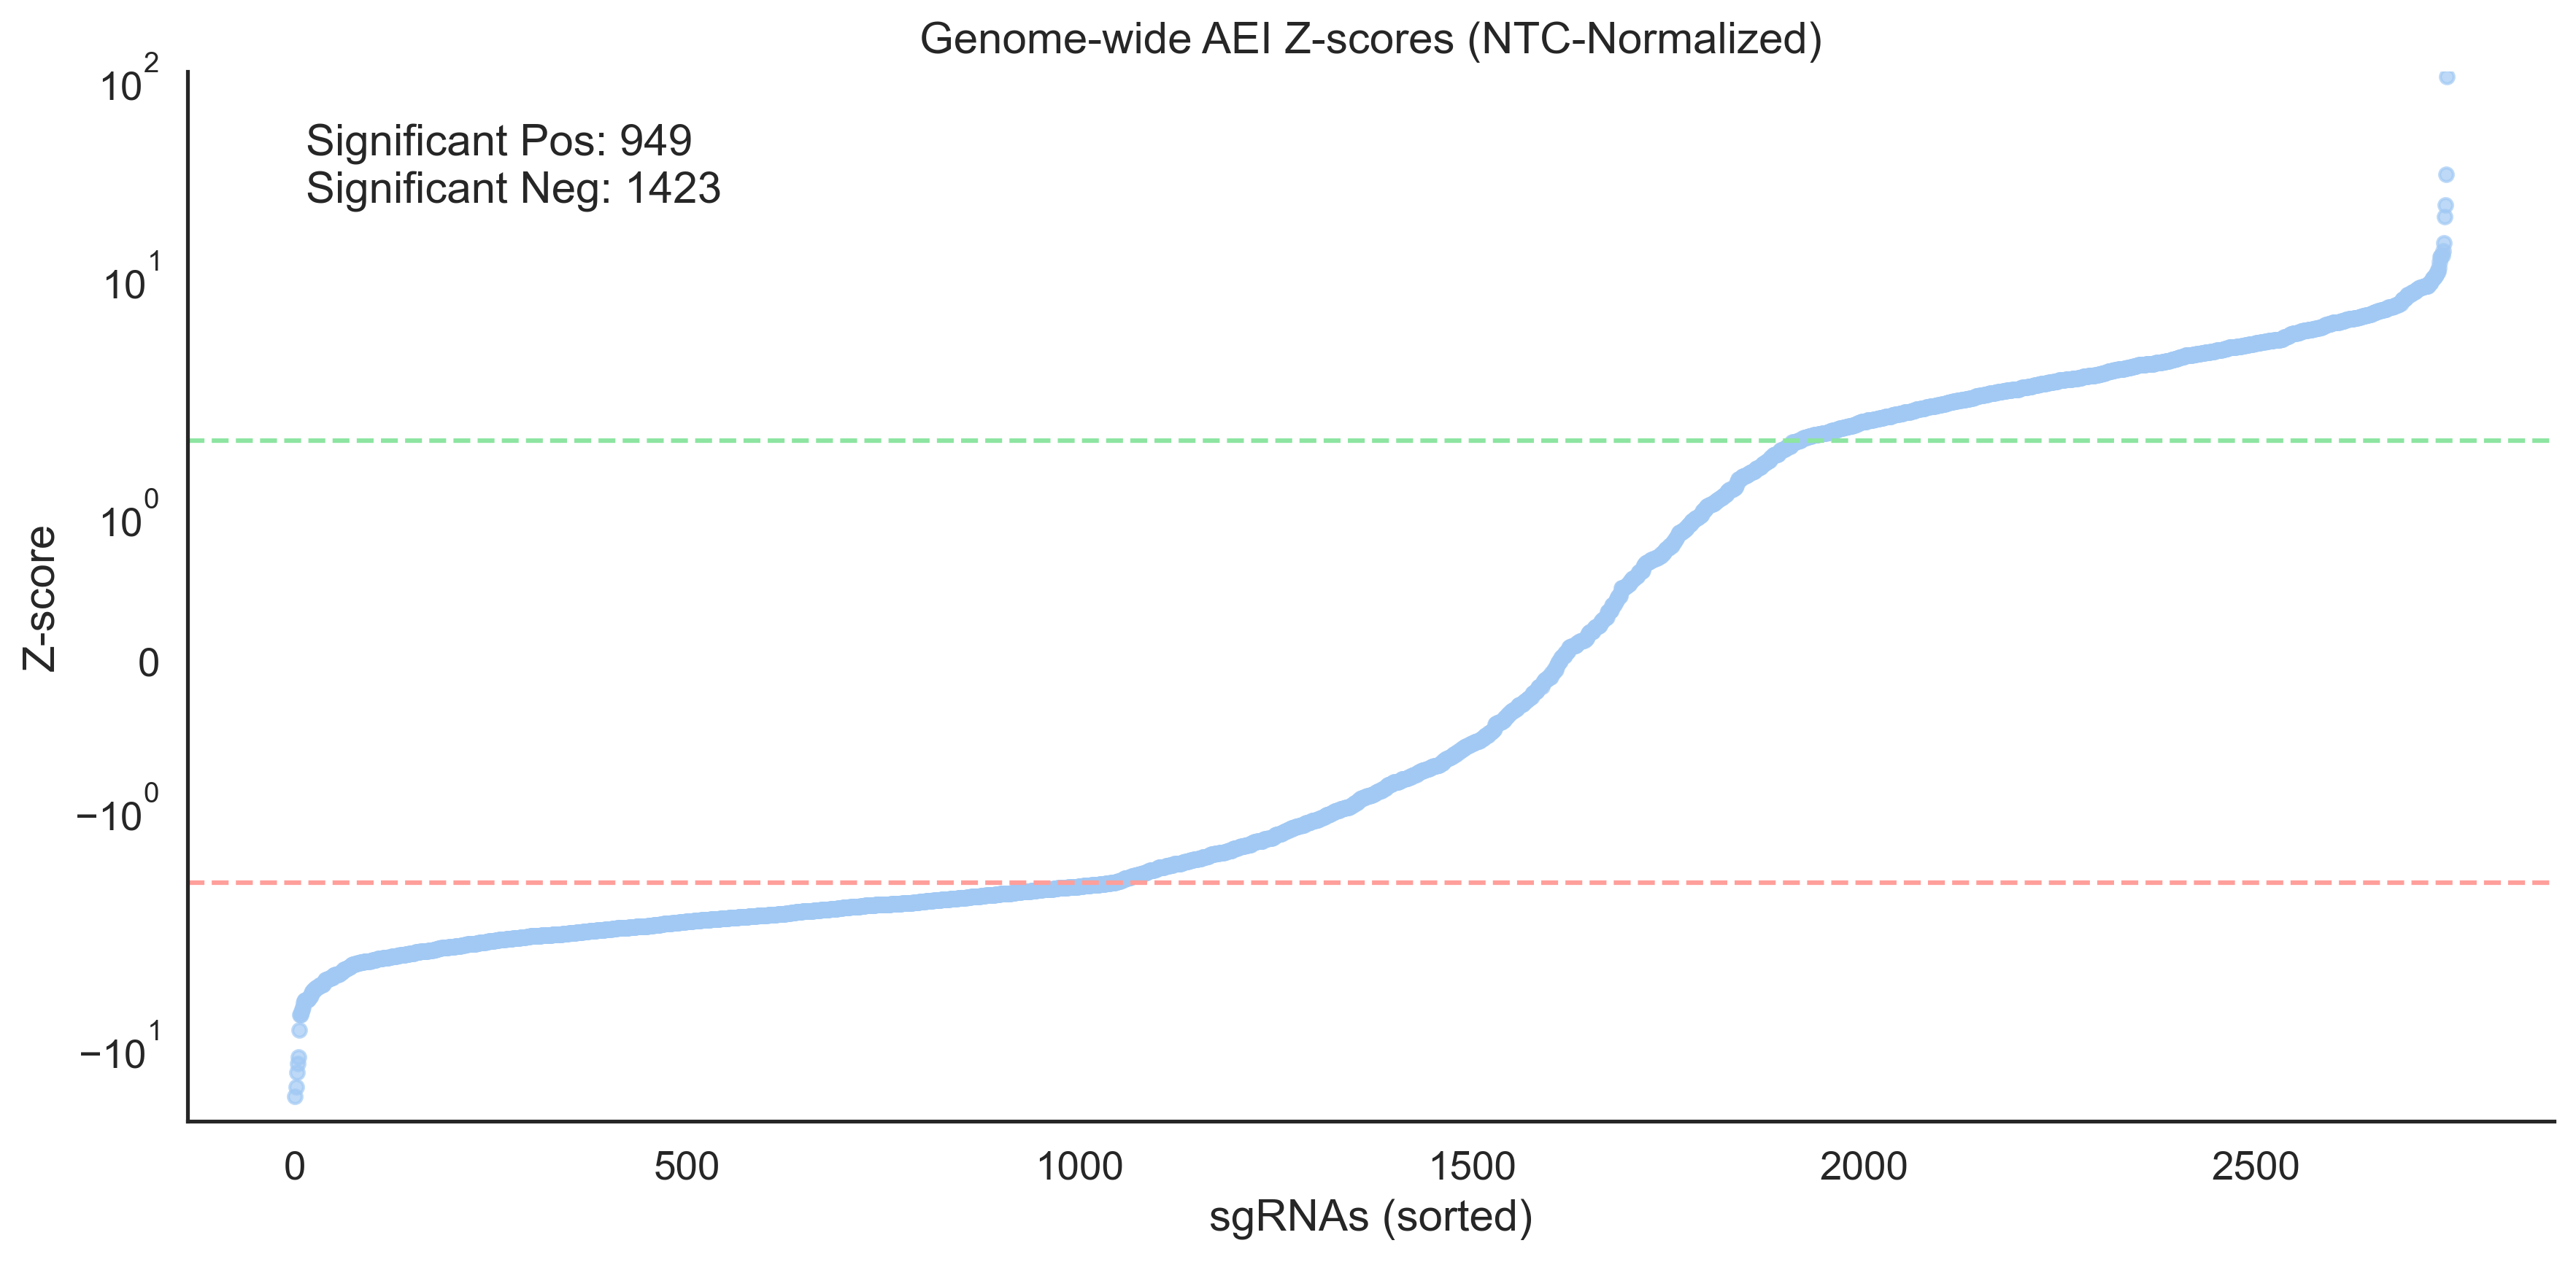

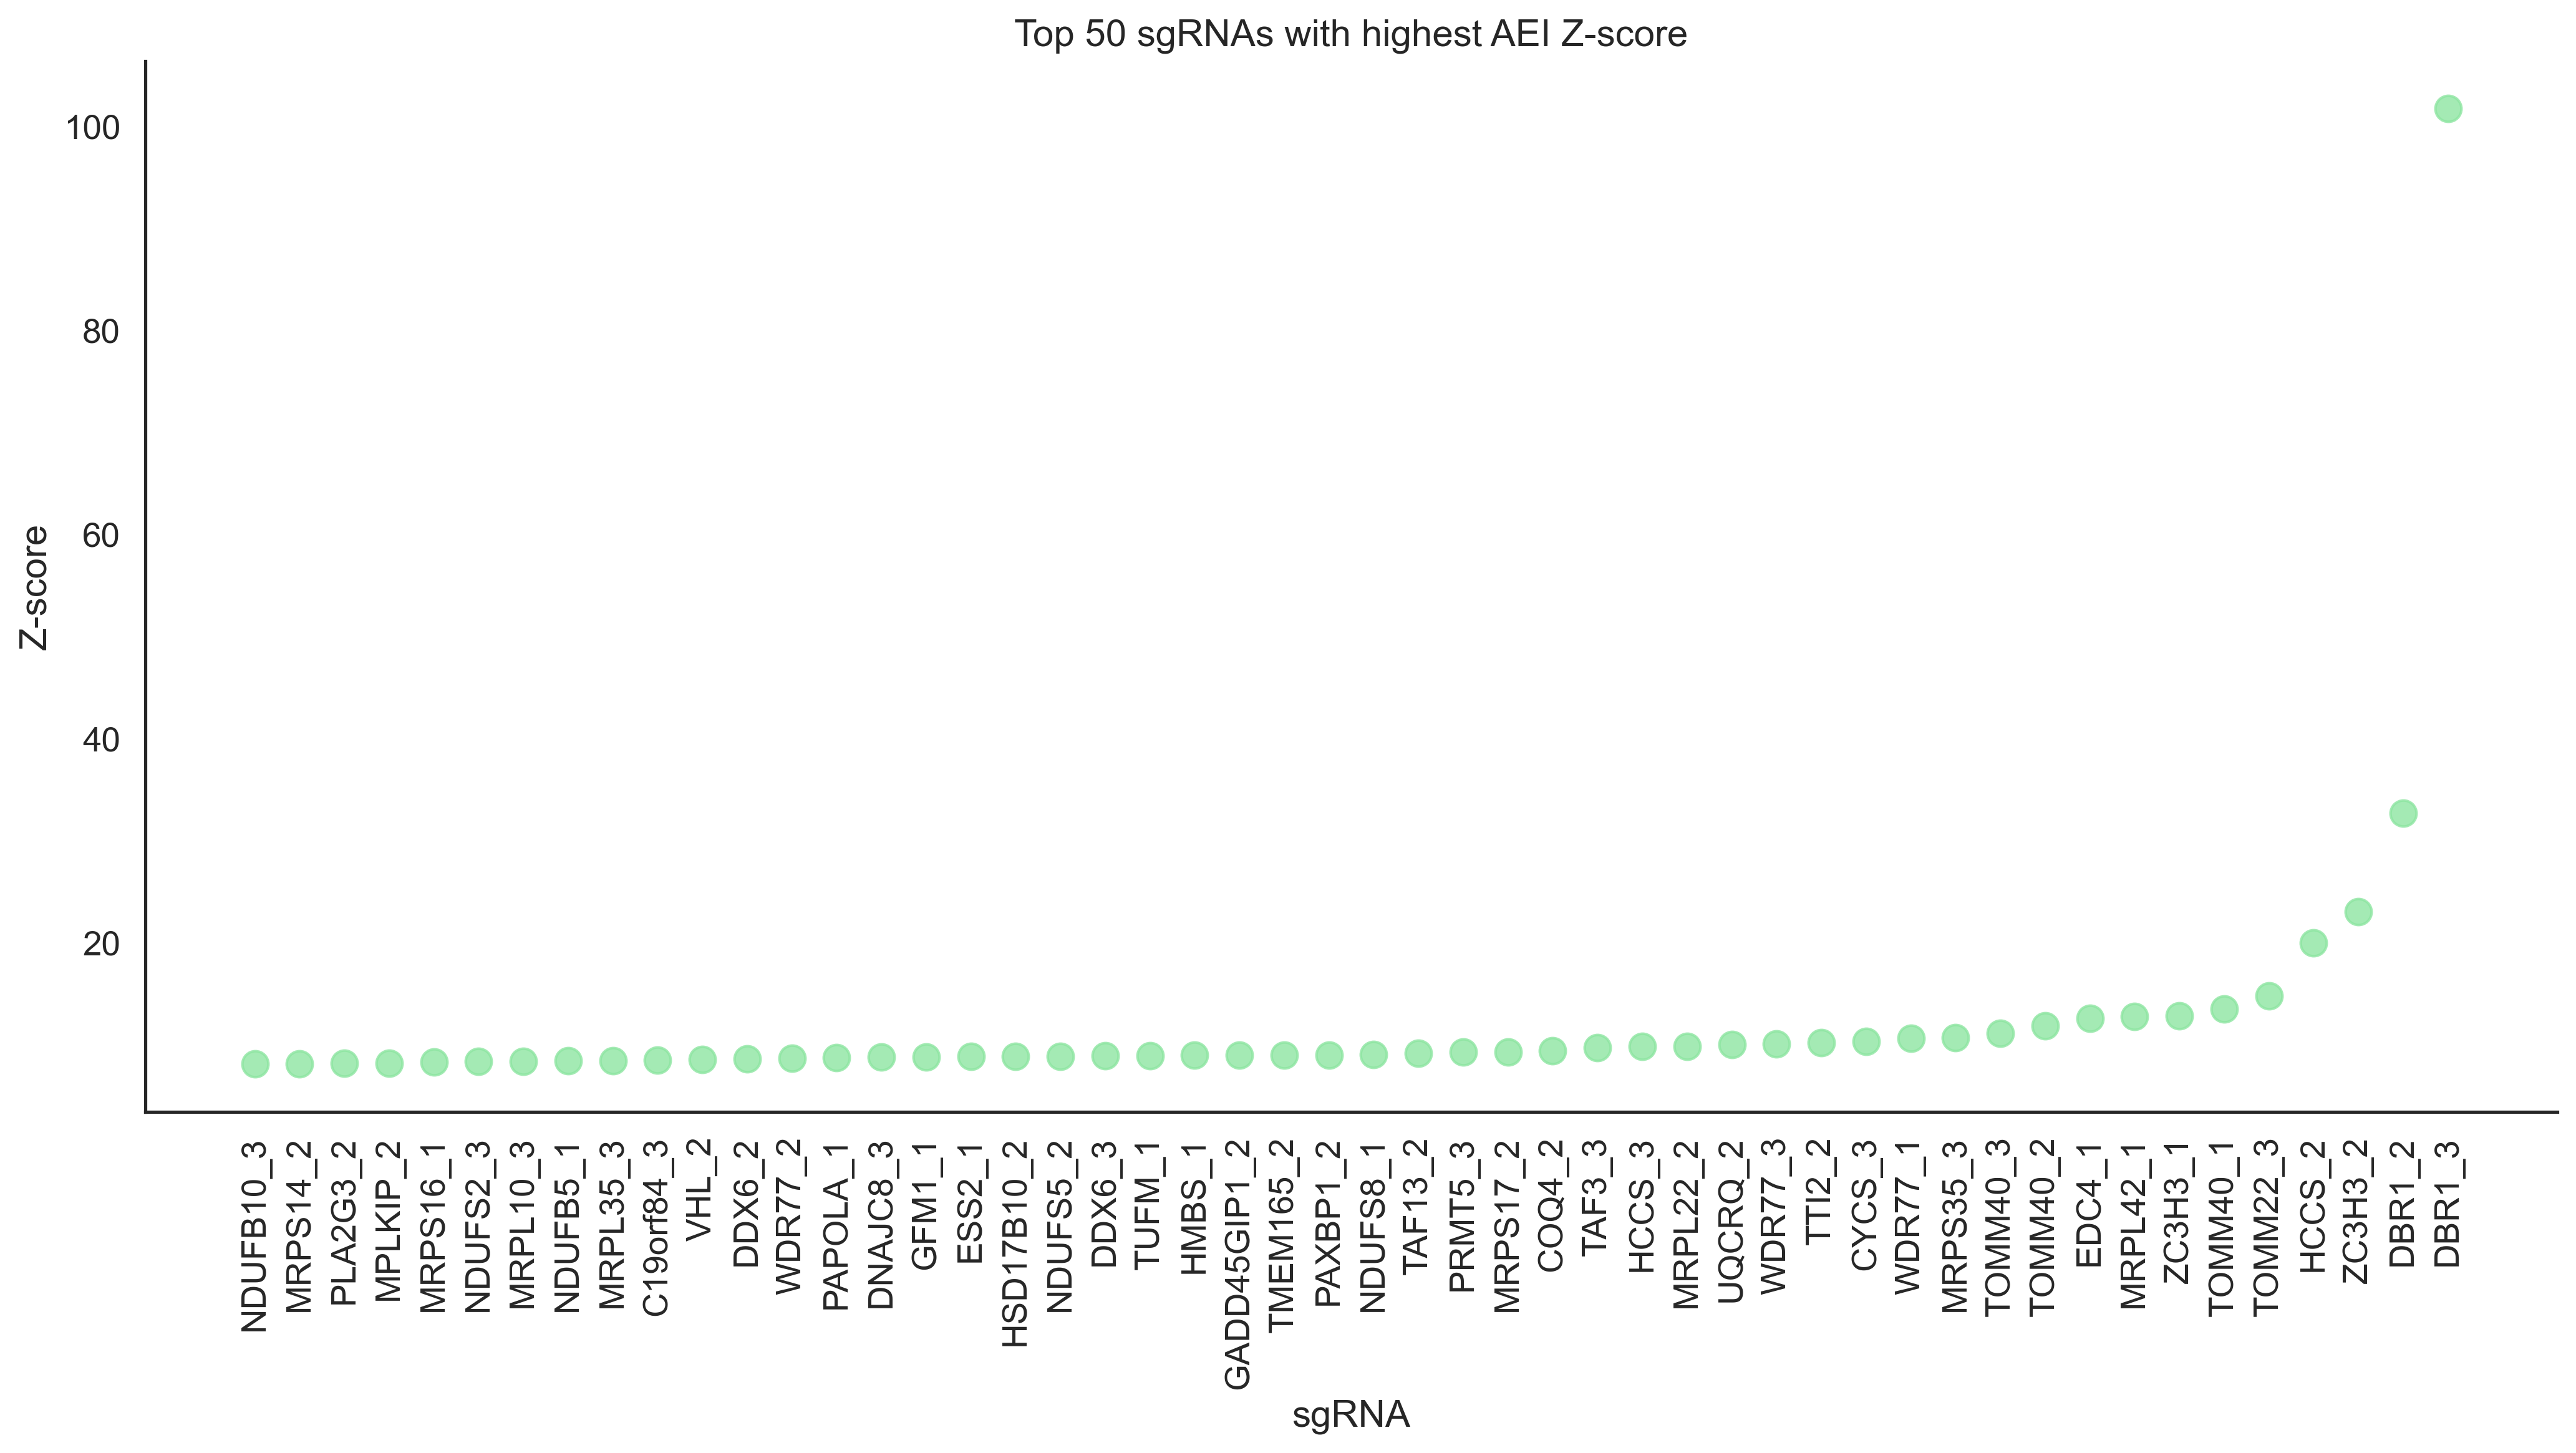

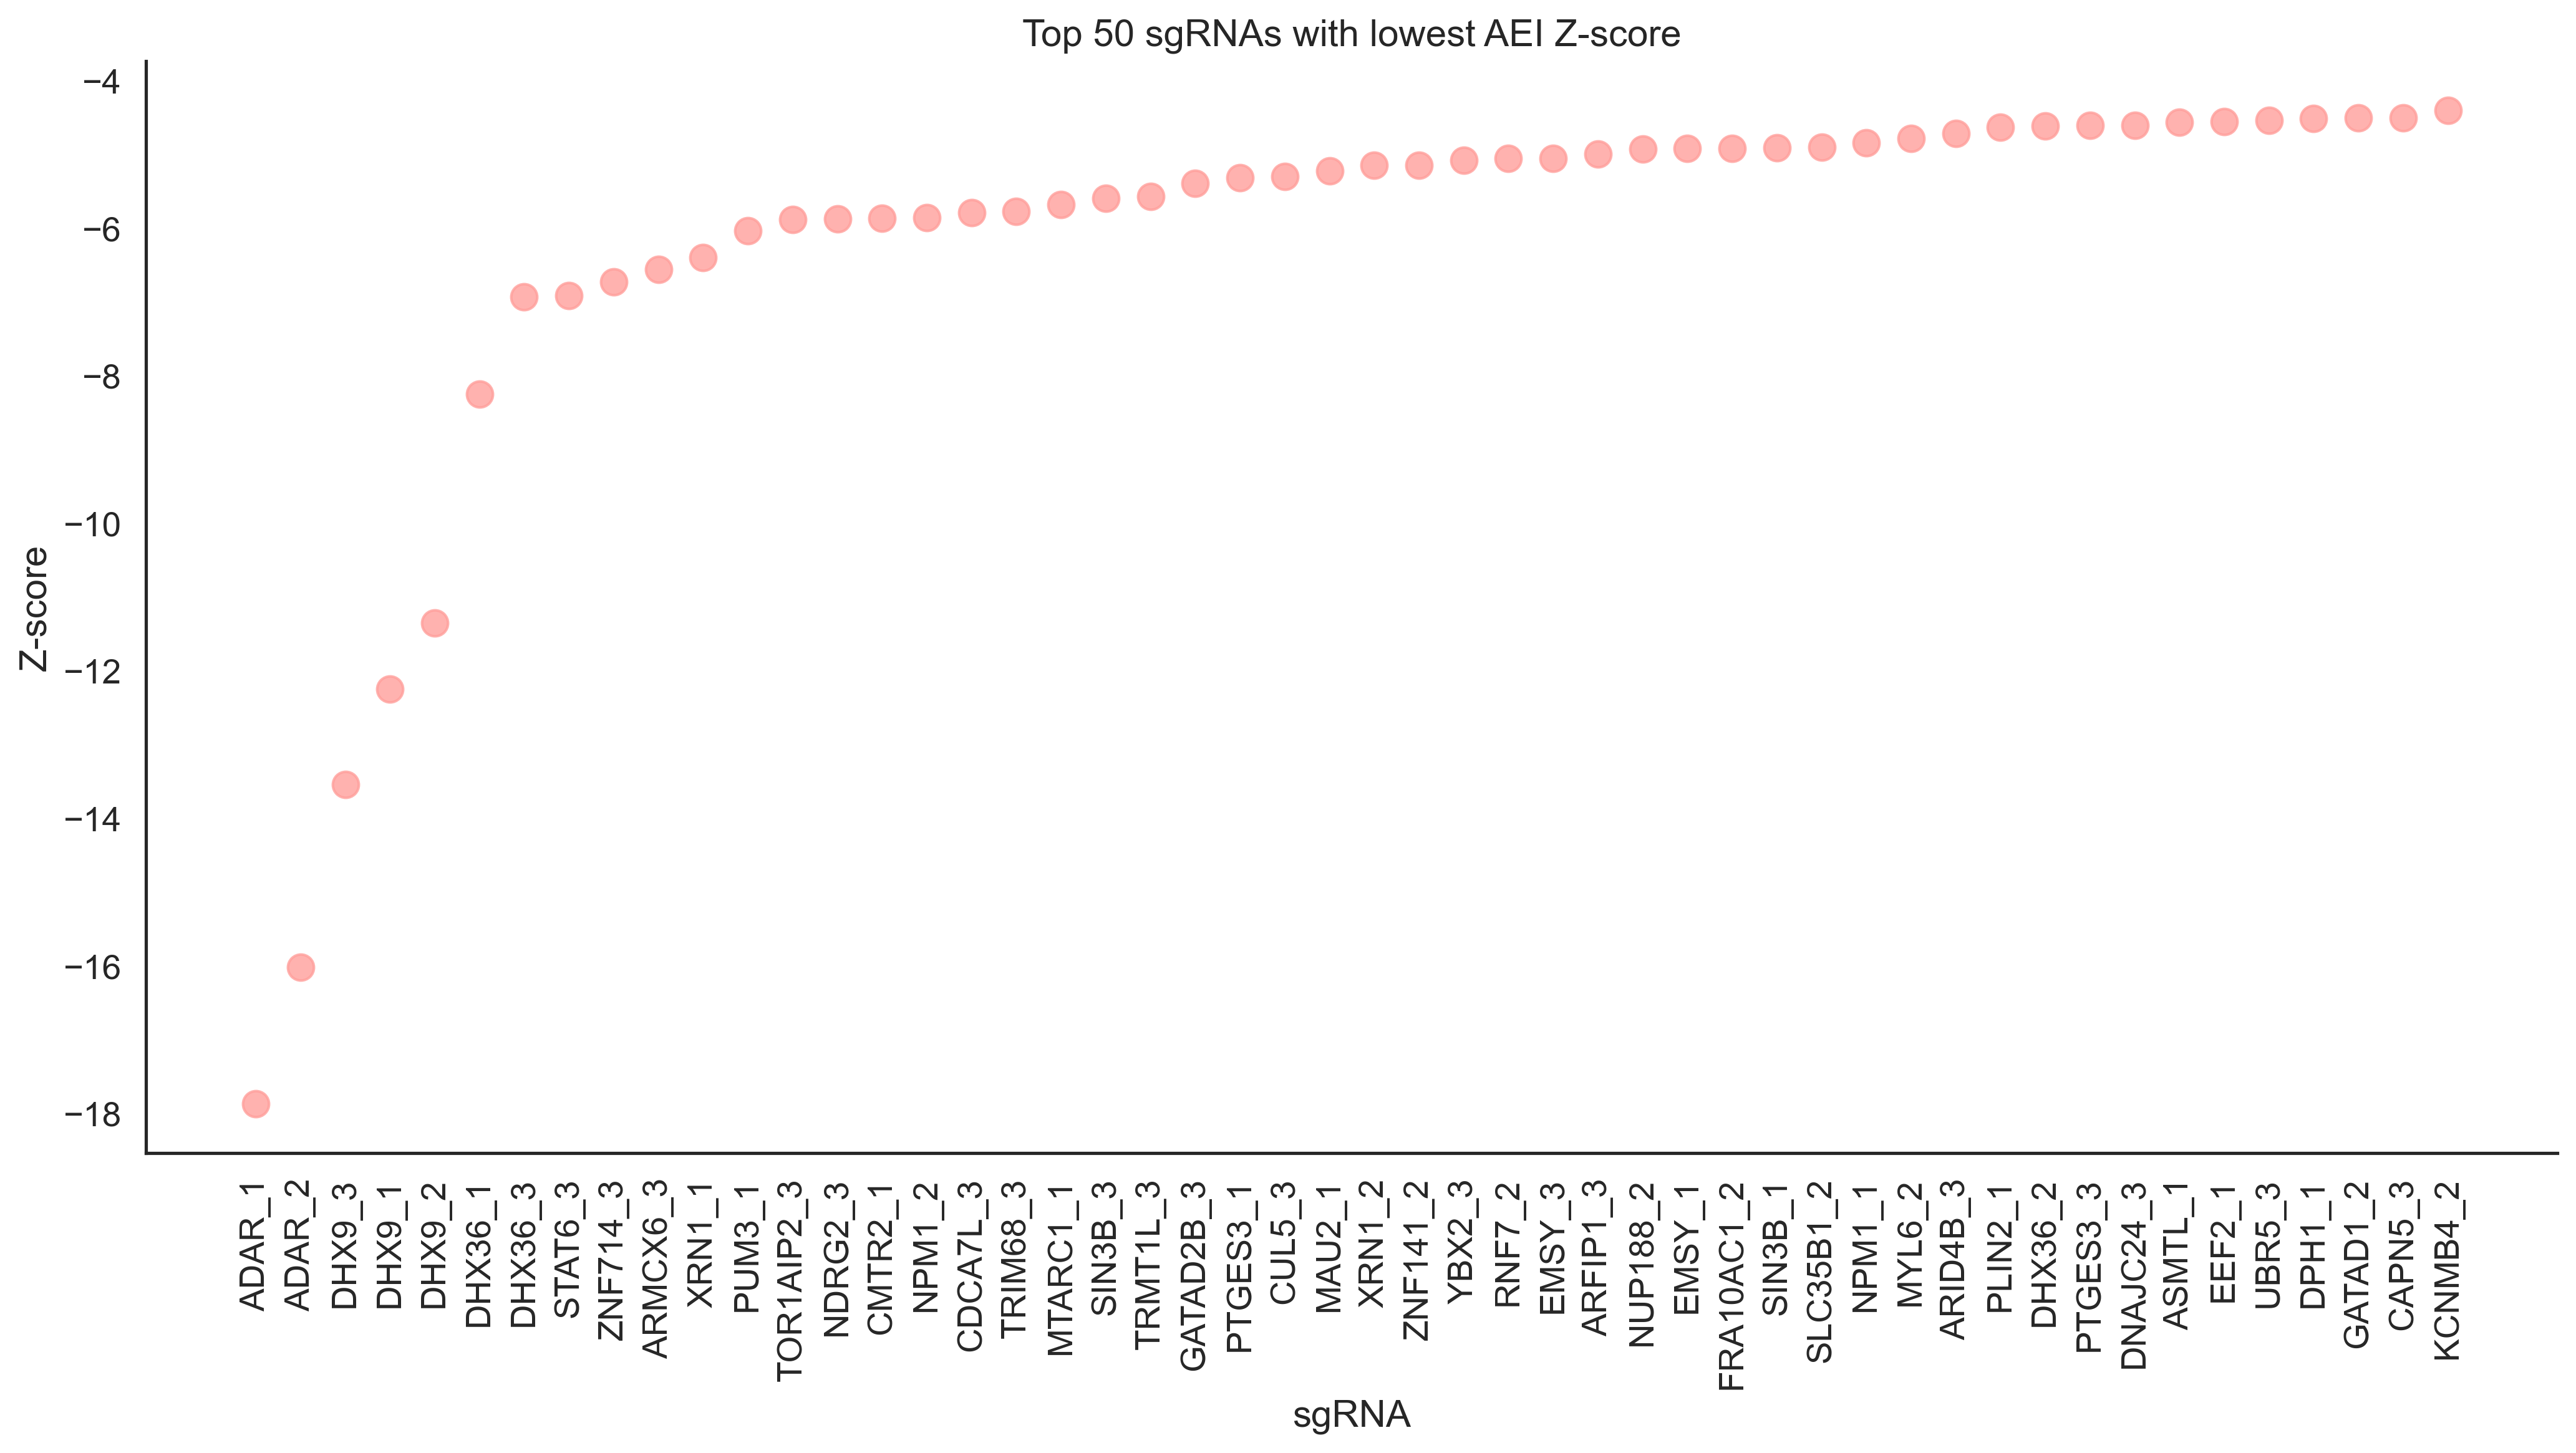

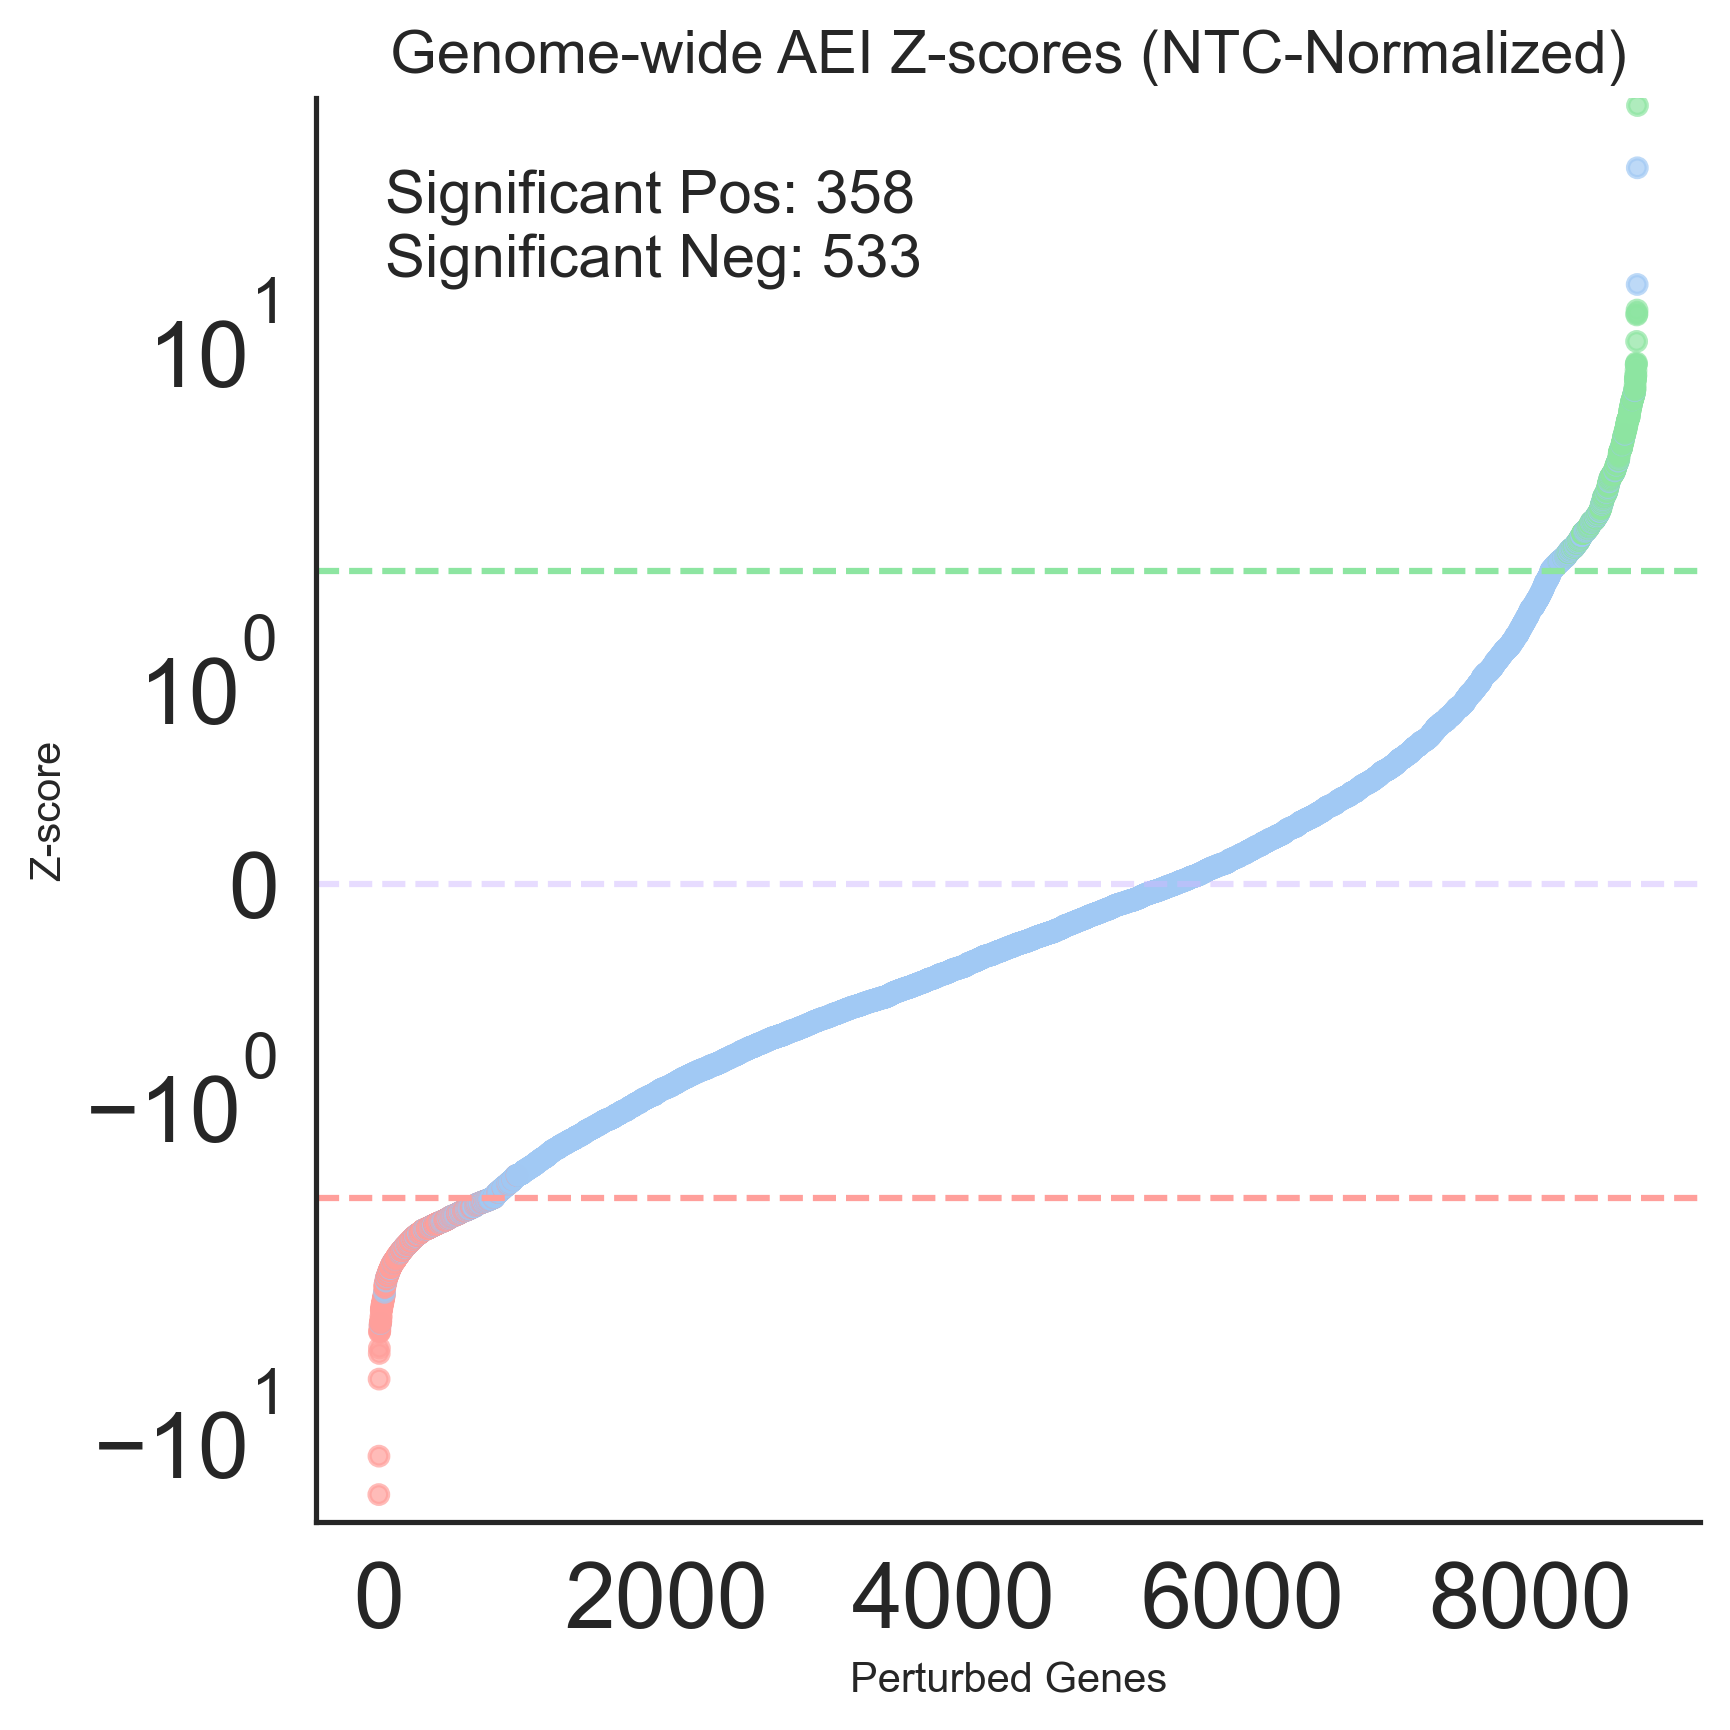

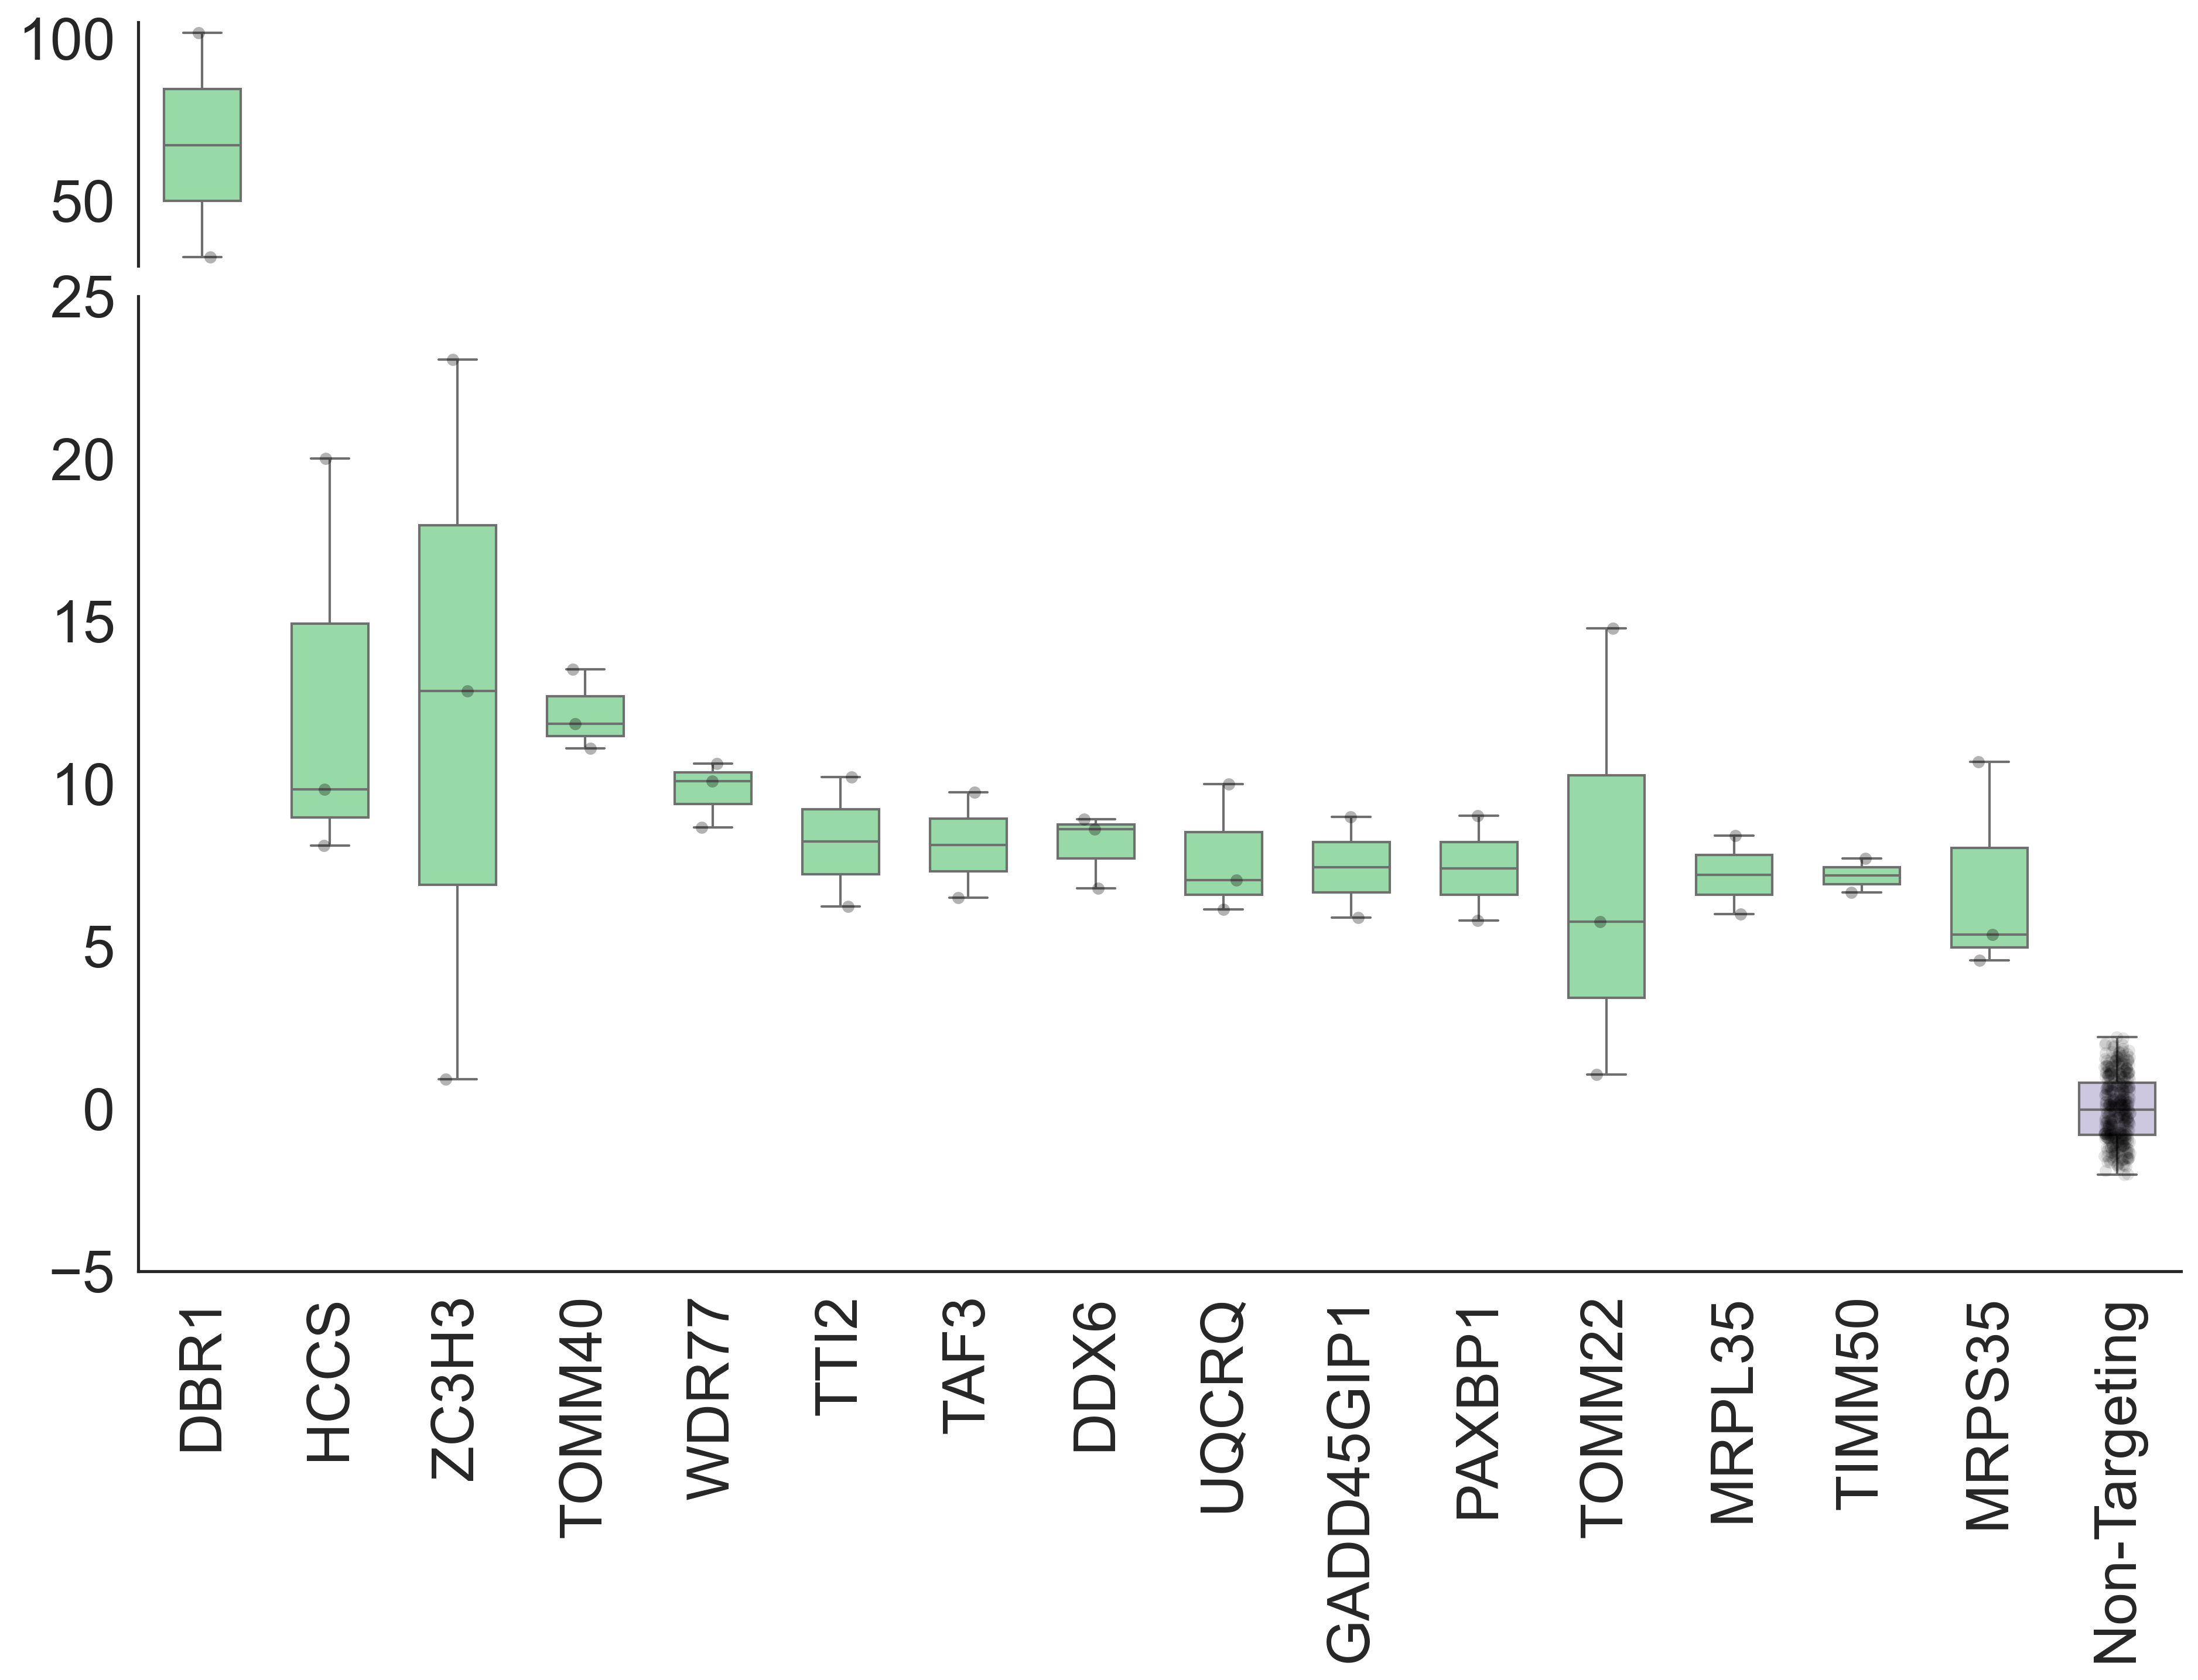

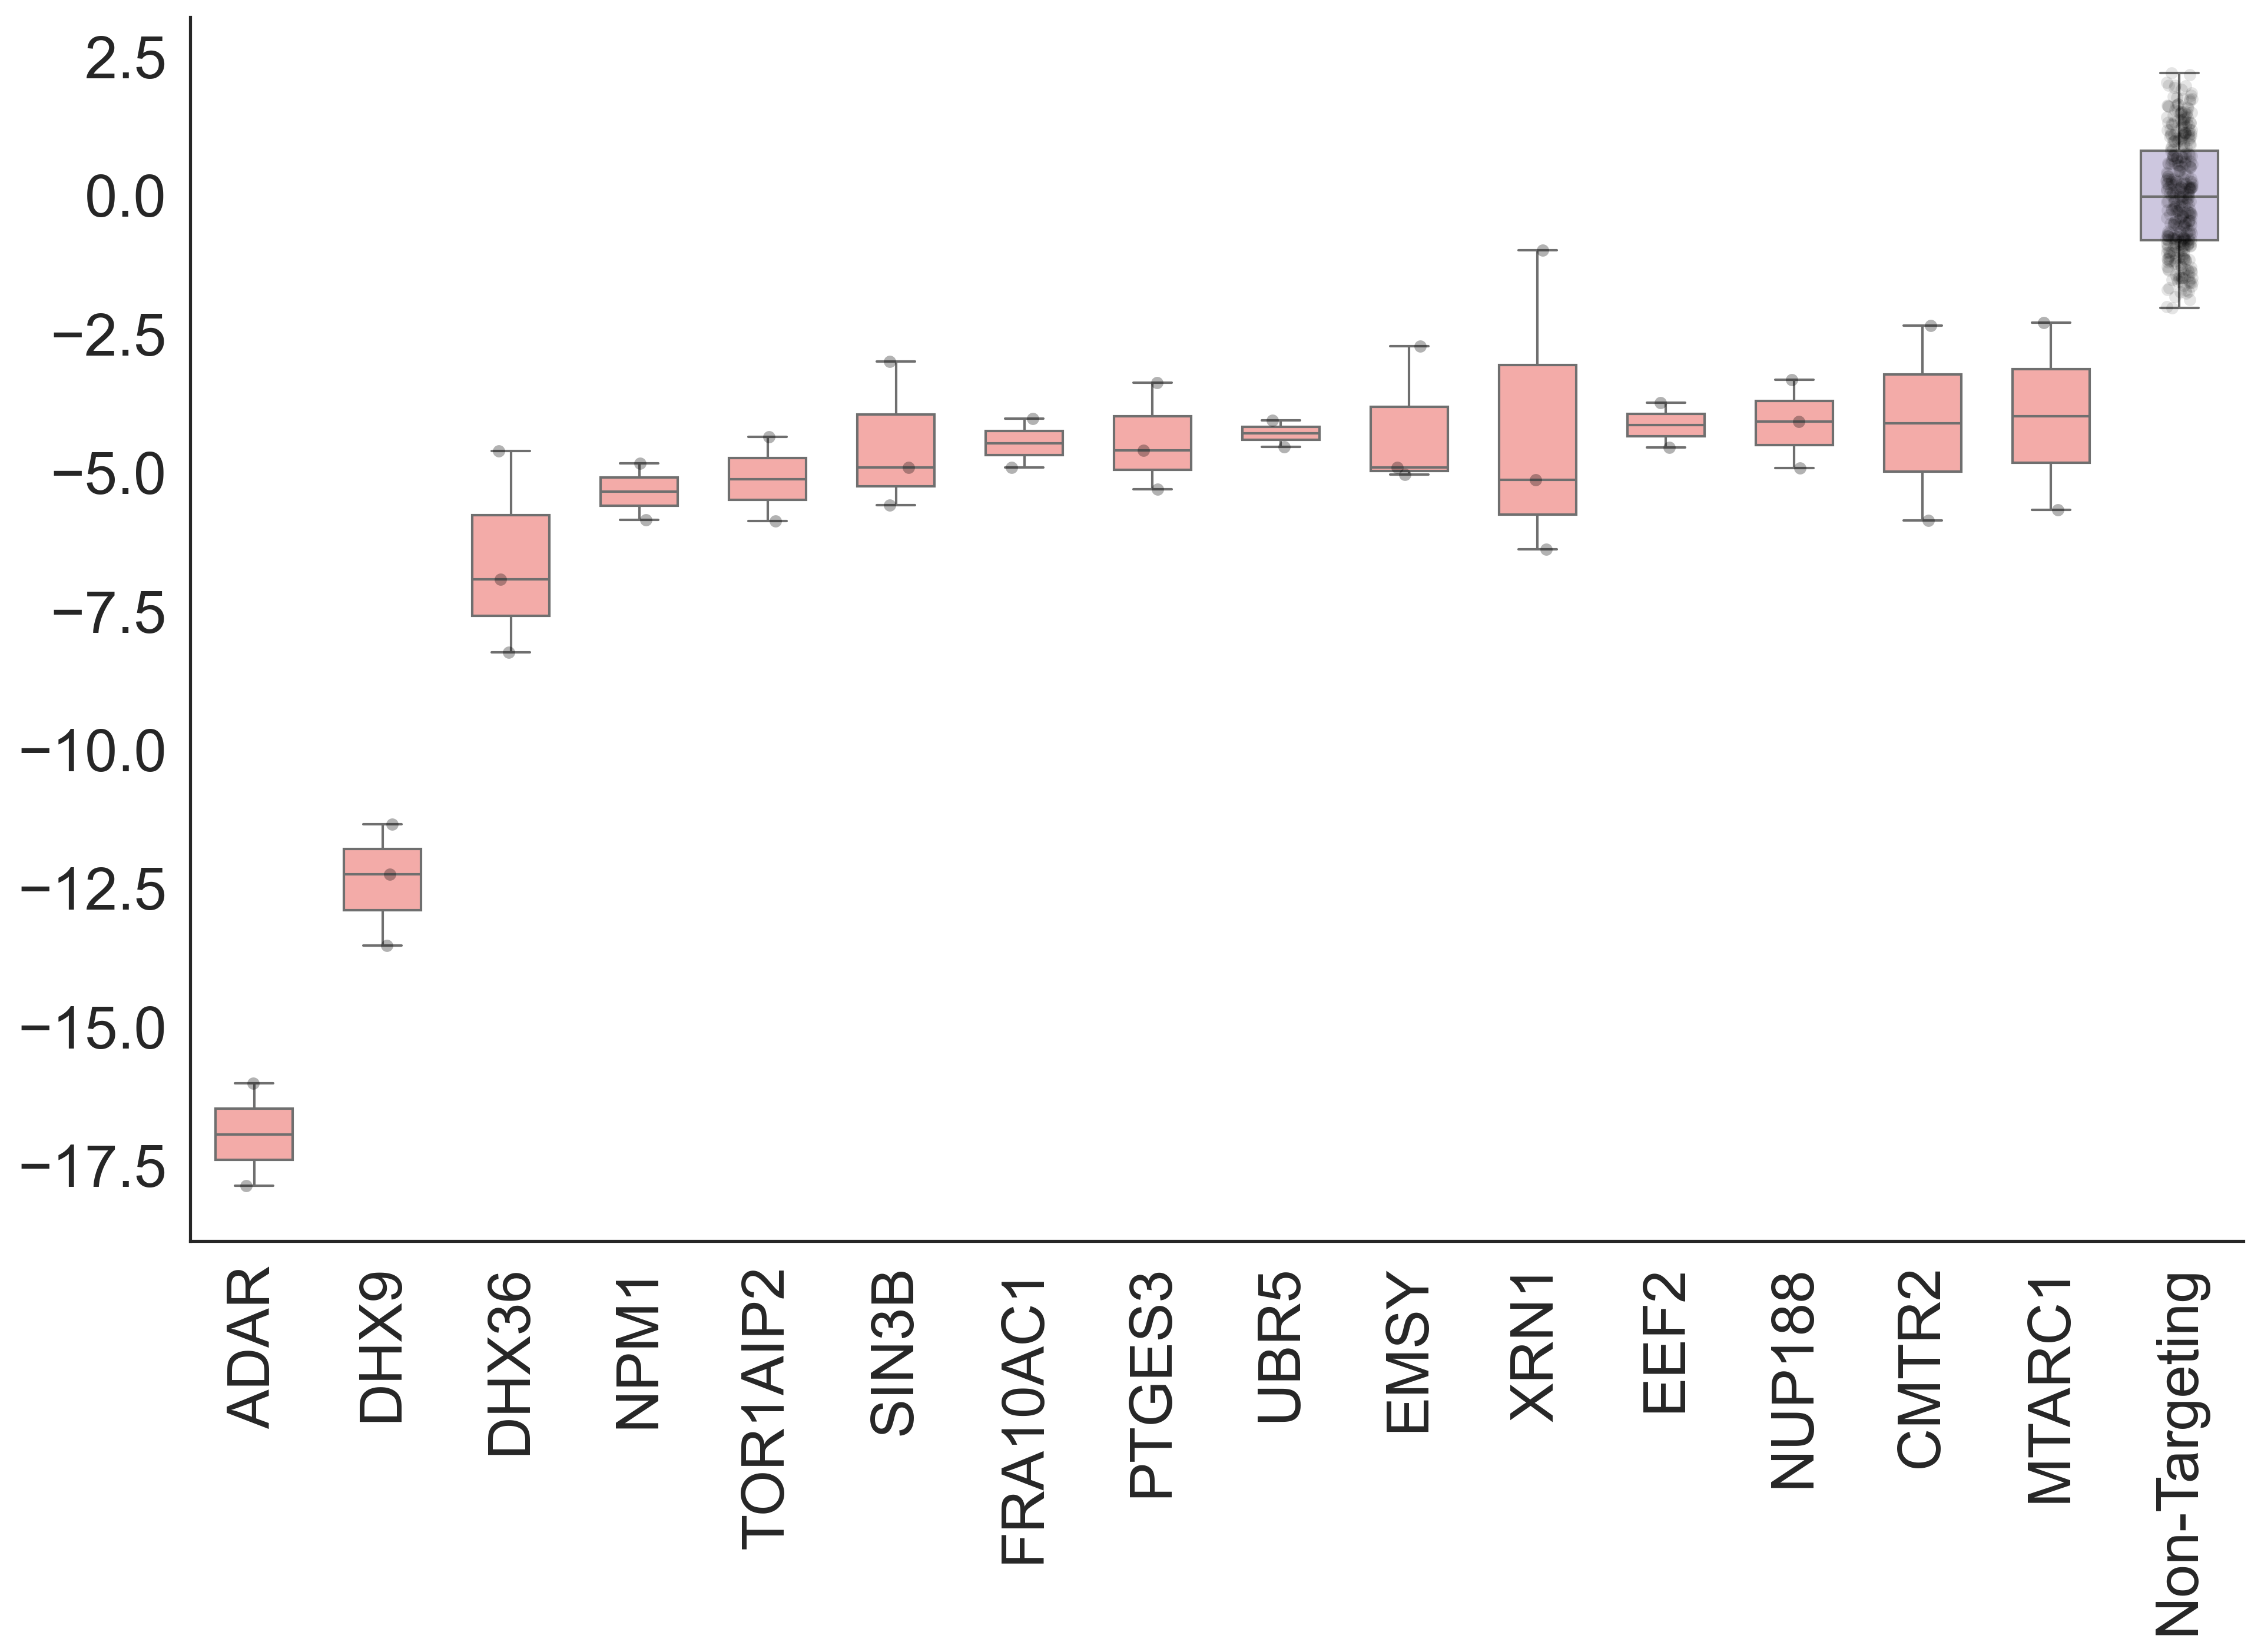

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from adjustText import adjust_text  # retained if needed later
plt.rcParams['font.family'] = 'Arial'

def setup_plot_style():
    """
    Set up the plotting style and return a dictionary of colors.
    
    Returns:
        dict: A dictionary containing the color palette and specific color assignments.
              Keys:
                  - 'COLOR_POS': Color for positive values.
                  - 'COLOR_NEG': Color for negative values.
                  - 'COLOR_NTC': Color for Non-Targeting (NTC).
                  - 'palette0': Primary color from the palette.
    """
    sns.set(style="white", font_scale=1.2)
    palette = sns.color_palette("pastel")
    return {
        'COLOR_POS': palette[2],  # Green
        'COLOR_NEG': palette[3],  # Red
        'COLOR_NTC': palette[4],  # Grey
        'palette0': palette[0]
    }

# Initialize plot style and colors
colors = setup_plot_style()
COLOR_POS = colors['COLOR_POS']
COLOR_NEG = colors['COLOR_NEG']
COLOR_NTC = colors['COLOR_NTC']
palette0 = colors['palette0']


def plot_all_sgrnas(merged_filtered):
    """
    Plot all sgRNAs sorted by z-score in a scatter plot.
    
    The function sorts the input DataFrame by the 'z_score' column, plots the values,
    draws horizontal lines at z = 2 and z = -2, and annotates the number of sgRNAs above
    and below these thresholds.
    
    Args:
        merged_filtered (pd.DataFrame): DataFrame containing sgRNA data with a 'z_score' column.
    
    Returns:
        matplotlib.figure.Figure: Figure object for the genome-wide AEI z-scores plot.
    """
    sorted_all = merged_filtered.sort_values('z_score')
    fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
    ax.scatter(x=np.arange(len(sorted_all)), y=sorted_all['z_score'],
               s=20, color=palette0, alpha=0.7)
    ax.axhline(1.5, color=COLOR_POS, linestyle='--', linewidth=1.5)
    ax.axhline(-1.5, color=COLOR_NEG, linestyle='--', linewidth=1.5)
    
    # Add annotation for counts above and below the threshold lines
    n_above = sum((sorted_all['z_score'] > 0) & (sorted_all['p_value_corrected'] < 0.05))
    n_below = sum((sorted_all['z_score'] < 0) & (sorted_all['p_value_corrected'] < 0.05))
    ax.text(0.05, 0.95, f'Significant Pos: {n_above}\nSignificant Neg: {n_below}',
            transform=ax.transAxes, va='top')
    
    ax.set_xlabel('sgRNAs (sorted)')
    ax.set_ylabel('Z-score')
    ax.set_title('Genome-wide AEI Z-scores (NTC-Normalized)')
    ax.set_yscale('symlog', linthresh=1.5, base=10)
    sns.despine(ax=ax)
    fig.tight_layout()
    return fig


def plot_all_genes(merged_filtered_gene_level):
    sorted_all = merged_filtered_gene_level.sort_values('Gene Average Z-Score')
    fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
    
    # Create color mapping based on p_value_corrected
    # Significant: p < 0.05 (red), Non-significant: p >= 0.05 (grey)
    colors = [
        COLOR_POS if (p < 0.05 and z > 0) else
        COLOR_NEG if (p < 0.05 and z < 0) else
        palette0
        for p, z in zip(sorted_all['p_value_corrected'], sorted_all['Gene Average Z-Score'])
    ]
    
    ax.scatter(x=np.arange(len(sorted_all)), y=sorted_all['Gene Average Z-Score'],
               s=20, c=colors, alpha=0.7)
    ax.axhline(1.5, color=COLOR_POS, linestyle='--', linewidth=1.5)
    ax.axhline(-1.5, color=COLOR_NEG, linestyle='--', linewidth=1.5)
    ax.axhline(0, color=COLOR_NTC, linestyle='--', linewidth=1.5, alpha=0.5)
    
    # Add annotation for counts above and below the threshold lines
    n_above = sum((sorted_all['Gene Average Z-Score'] > 0) & (sorted_all['p_value_corrected'] < 0.05))
    n_below = sum((sorted_all['Gene Average Z-Score'] < 0) & (sorted_all['p_value_corrected'] < 0.05))
    ax.text(0.05, 0.95, f'Significant Pos: {n_above}\nSignificant Neg: {n_below}',
            transform=ax.transAxes, va='top')
    
    ax.set_xlabel('Perturbed Genes', fontsize=10)
    ax.set_ylabel('Z-score', fontsize=10)
    ax.set_title('Genome-wide AEI Z-scores (NTC-Normalized)')
    ax.set_yscale('symlog', linthresh=1.5, base=10)
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.tick_params(axis='both', which='minor', labelsize=22)
    sns.despine(ax=ax)
    fig.tight_layout()
    return fig


def plot_top_positive_sgrnas(merged_filtered):
    """
    Plot the top 50 sgRNAs with the highest AEI z-scores.
    
    The function selects the 50 sgRNAs with the highest z-scores, sorts them in ascending order,
    and creates a scatter plot with sgRNA labels on the x-axis.
    
    Args:
        merged_filtered (pd.DataFrame): DataFrame containing sgRNA data with a 'z_score' column.
    
    Returns:
        matplotlib.figure.Figure: Figure object for the top positive sgRNAs plot.
    """
    top_pos = merged_filtered.nlargest(50, 'z_score').reset_index(drop=True)
    top_pos = top_pos.sort_values('z_score')
    
    fig, ax = plt.subplots(figsize=(14, 8), dpi=300)
    ax.scatter(np.arange(len(top_pos)), top_pos['z_score'], 
               color=COLOR_POS, s=100, alpha=0.8)
    ax.set_xticks(np.arange(len(top_pos)))
    ax.set_xticklabels(top_pos['sgRNA'], rotation=90)
    ax.set_xlabel('sgRNA')
    ax.set_ylabel('Z-score')
    ax.set_title('Top 50 sgRNAs with highest AEI Z-score')
    sns.despine(ax=ax)
    fig.tight_layout()
    return fig


def plot_top_negative_sgrnas(merged_filtered):
    """
    Plot the top 50 sgRNAs with the lowest (most negative) AEI z-scores.
    
    The function selects the 50 sgRNAs with the lowest z-scores, sorts them in ascending order,
    and creates a scatter plot with sgRNA labels on the x-axis.
    
    Args:
        merged_filtered (pd.DataFrame): DataFrame containing sgRNA data with a 'z_score' column.
    
    Returns:
        matplotlib.figure.Figure: Figure object for the top negative sgRNAs plot.
    """
    top_neg = merged_filtered.nsmallest(50, 'z_score').reset_index(drop=True)
    top_neg = top_neg.sort_values('z_score')
    
    fig, ax = plt.subplots(figsize=(14, 8), dpi=300)
    ax.scatter(np.arange(len(top_neg)), top_neg['z_score'], 
               color=COLOR_NEG, s=100, alpha=0.8)
    ax.set_xticks(np.arange(len(top_neg)))
    ax.set_xticklabels(top_neg['sgRNA'], rotation=90)
    ax.set_xlabel('sgRNA')
    ax.set_ylabel('Z-score')
    ax.set_title('Top 50 sgRNAs with lowest AEI Z-score')
    sns.despine(ax=ax)
    fig.tight_layout()
    return fig

def plot_gene_level_boxplot(merged_filtered, n=10):
    """
    Create separate gene-level boxplots for the top n positive and bottom n negative editing effects.
    
    This function performs the following steps:
        1. Computes the mean z-score for each gene.
        2. Excludes the non-targeting control from extreme selection.
        3. Selects the top n positive and bottom n negative genes.
        4. Ensures the non-targeting control is included (if present).
        5. Sorts the selected genes by increasing mean z-score.
        6. Creates a custom color palette.
        7. Filters the DataFrame and plots boxplots of the z-scores, 
           with individual sgRNA data points overlaid using alpha=0.5 for non-NTC points and alpha=0.03 for NTC.
    
    Args:
        merged_filtered (pd.DataFrame): DataFrame containing sgRNA data with columns 'Gene' and 'z_score'.
        n (int): Number of top positive and bottom negative genes to select.
    
    Returns:
        tuple: Two matplotlib.figure.Figure objects for the top and bottom gene-level boxplots.
    """
    # 1. Compute the mean z-score for each gene
    gene_means = merged_filtered.groupby("Gene")["z_score"].mean().reset_index()

    # Determine the actual label for non-targeting controls.
    if "Non-Targeting" in gene_means["Gene"].values:
        ntc_label = "Non-Targeting"
    elif "NTC" in gene_means["Gene"].values:
        ntc_label = "NTC"
    else:
        ntc_label = None

    # 2. Exclude the non-targeting control from extreme selection if it exists
    if ntc_label:
        gene_extremes = gene_means[gene_means["Gene"] != ntc_label]
    else:
        gene_extremes = gene_means.copy()

    # 3. Select top n positive and bottom n negative genes from the extremes
    top_pos_genes = gene_extremes.nlargest(n, "z_score")["Gene"].tolist()
    bottom_neg_genes = gene_extremes.nsmallest(n, "z_score")["Gene"].tolist()
    if ntc_label is not None:
        top_pos_genes.append(ntc_label)
        bottom_neg_genes.append(ntc_label)
    selected_genes = bottom_neg_genes + top_pos_genes

    # 4. Ensure that the non-targeting control is included if present
    if ntc_label and ntc_label not in selected_genes:
        selected_genes.append(ntc_label)

    # 5. Sort the selected genes by mean z-score (from low to high)
    selected_gene_means = gene_means[gene_means["Gene"].isin(selected_genes)]
    final_gene_order = selected_gene_means.sort_values("z_score")["Gene"].tolist()

    # Ensure the non-targeting control is last in the order if it exists
    if ntc_label in final_gene_order:
        final_gene_order.remove(ntc_label)
        final_gene_order.append(ntc_label)

    # 6. Create a custom color palette mapping for the genes
    gene_palette = {}
    for gene in final_gene_order:
        if ntc_label and gene == ntc_label:
            gene_palette[gene] = "#CBC3E3"  # Use light purple for non-targeting controls
        else:
            mean_val = selected_gene_means[selected_gene_means["Gene"] == gene]["z_score"].iloc[0]
            gene_palette[gene] = COLOR_POS if mean_val > 0 else COLOR_NEG

    # 7. Filter the DataFrame to include only the selected genes
    data_subset = merged_filtered[merged_filtered["Gene"].isin(final_gene_order)]

    # 8. Create the boxplots for top positive genes with overlaid individual data points
    # Create a figure with broken y-axis
    fig_top = plt.figure(figsize=(15, 9), dpi=300)
    
    # Create two subplots with different heights (top one smaller)
    gs = fig_top.add_gridspec(2, 1, height_ratios=[1, 4], hspace=0.05)
    ax_top_upper = fig_top.add_subplot(gs[0])
    ax_top_lower = fig_top.add_subplot(gs[1])
    
    # Set the y-limits for the broken axis
    ax_top_upper.set_ylim(30, 105)  # Upper panel shows 35-105
    ax_top_lower.set_ylim(-5, 25)    # Lower panel shows -10-25
    
    # Create boxplots on both axes
    for ax in [ax_top_upper, ax_top_lower]:
        sns.boxplot(
            data=data_subset[data_subset["Gene"].isin(top_pos_genes)],
            x="Gene",
            y="z_score",
            order=top_pos_genes,
            palette=gene_palette,
            hue="Gene",
            linewidth=1,
            width=0.6,
            ax=ax
        )
        
        # Overlay individual data points with different alpha values based on gene label
        if ntc_label:
            top_non_ntc = data_subset[(data_subset["Gene"].isin(top_pos_genes)) & (data_subset["Gene"] != ntc_label)]
            top_ntc = data_subset[data_subset["Gene"] == ntc_label]
        else:
            top_non_ntc = data_subset[data_subset["Gene"].isin(top_pos_genes)]
            top_ntc = None

        sns.stripplot(
            data=top_non_ntc,
            x="Gene",
            y="z_score",
            order=top_pos_genes,
            color="black",
            alpha=0.3,
            jitter=True,
            ax=ax
        )
        
        if ntc_label and top_ntc is not None and not top_ntc.empty:
            sns.stripplot(
                data=top_ntc,
                x="Gene",
                y="z_score",
                order=top_pos_genes,
                color="black",
                alpha=0.1,
                jitter=True,
                ax=ax
            )
    
    # Hide x-axis labels and line on the top subplot
    ax_top_upper.set_xticklabels([])
    ax_top_upper.set_xlabel('')
    ax_top_upper.spines['bottom'].set_visible(False)
    
    # Set x-axis labels on the bottom subplot
    ax_top_lower.tick_params(axis="x", rotation=90)
    
    # Remove individual y-axis labels and add a single one for the figure
    ax_top_upper.set_ylabel('')
    ax_top_lower.set_ylabel('')
    ax_top_upper.spines['bottom'].set_linewidth(0)
    
    # Remove spines
    sns.despine(ax=ax_top_upper)
    sns.despine(ax=ax_top_lower)
    
    # Adjust layout
    plt.subplots_adjust(top=0.9)  # Make room for the title

    # Create the boxplots for bottom negative genes with overlaid individual data points
    fig_bottom, ax_bottom = plt.subplots(figsize=(15, 9), dpi=300)
    sns.boxplot(
        data=data_subset[data_subset["Gene"].isin(bottom_neg_genes)],
        x="Gene",
        y="z_score",
        order=bottom_neg_genes,
        palette=gene_palette,
        hue="Gene",
        linewidth=1,
        width=0.6,
        ax=ax_bottom
    )
    # Overlay individual data points with conditionally set alpha values
    if ntc_label:
        bottom_non_ntc = data_subset[(data_subset["Gene"].isin(bottom_neg_genes)) & (data_subset["Gene"] != ntc_label)]
        bottom_ntc = data_subset[data_subset["Gene"] == ntc_label]
    else:
        bottom_non_ntc = data_subset[data_subset["Gene"].isin(bottom_neg_genes)]
        bottom_ntc = None

    sns.stripplot(
        data=bottom_non_ntc,
        x="Gene",
        y="z_score",
        order=bottom_neg_genes,
        color="black",
        alpha=0.3,
        jitter=True,
        ax=ax_bottom
    )
    if ntc_label and bottom_ntc is not None and not bottom_ntc.empty:
        sns.stripplot(
            data=bottom_ntc,
            x="Gene",
            y="z_score",
            order=bottom_neg_genes,
            color="black",
            alpha=0.1,
            jitter=True,
            ax=ax_bottom
        )
    ax_bottom.tick_params(axis="x", rotation=90)
    sns.despine(ax=ax_bottom)
    ax_top_lower.tick_params(axis='both', labelsize=24)
    ax_bottom.tick_params(axis='both', labelsize=24)
    ax_top_upper.tick_params(axis='both', labelsize=24, width=3)
    ax_top_lower.tick_params(axis='both', labelsize=24, width=3)
    ax_bottom.tick_params(axis='both', labelsize=24, width=3)
    ax_top_lower.set_xlabel("")
    ax_bottom.set_xlabel("")
    ax_bottom.set_ylabel("")

    return fig_top, fig_bottom

sgRNA_z_score_plot = plot_all_sgrnas(significant_genes)
top_positive_sgRNAs_plot = plot_top_positive_sgrnas(significant_genes)
top_negative_sgRNAs_plot = plot_top_negative_sgrnas(significant_genes)
fig = plot_all_genes(merged_filtered_gene_level)
fig.savefig("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs/Figures/AEI_All_Genes_Z_Score_Plot.svg")
fig.savefig("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs/Figures/AEI_All_Genes_Z_Score_Plot.png", dpi=1200)
fig1, fig2 = gene_level_boxplot = plot_gene_level_boxplot(significant_genes,n=15)
fig1.savefig("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs/Figures/AEI_Top_Positive_Gene_Level_Editing_Effects.svg")
fig2.savefig("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_outputs/Figures/AEI_Bottom_Negative_Gene_Level_Editing_Effects.svg")


In [ ]:
merged_filtered_gene_level

In [12]:
def pval_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

df = merged_filtered_gene_level.sort_values('Gene Average Z-Score').head(20).copy()
df['stars'] = df['p_value_corrected'].apply(pval_to_stars)
df[['Batch', 'Gene', 'Gene Average AEI', 'Gene Average Z-Score', 'p_value_corrected', 'stars']]

,Batch,Gene,Gene Average AEI,Gene Average Z-Score,p_value_corrected,stars
2245,ALPHA,ADAR,0.725524,-16.938745,0.006102,**
1836,ALPHA,DHX9,0.777669,-12.376925,0.003239,**
1857,ALPHA,DHX36,0.843744,-6.596403,0.002499,**
1289,ALPHA,NPM1,0.858000,-5.349227,0.006102,**
4361,BETA,TOR1AIP2,0.988099,-5.121435,0.006102,**
1020,ALPHA,SIN3B,0.867692,-4.501297,0.001749,**
8660,GAMMA,FRA10AC1,0.860694,-4.474022,0.006102,**
5631,BETA,PTGES3,0.997681,-4.430419,0.001749,**
2557,ALPHA,UBR5,0.870007,-4.298760,0.006102,**
2059,ALPHA,EMSY,0.870815,-4.228118,0.002499,**


In [13]:
def pval_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

df = merged_filtered_gene_level.sort_values('Gene Average Z-Score').tail(20)[::-1].copy()
df['stars'] = df['p_value_corrected'].apply(pval_to_stars)
df[['Batch', 'Gene', 'Gene Average AEI', 'Gene Average Z-Score', 'p_value_corrected', 'stars']]

,Batch,Gene,Gene Average AEI,Gene Average Z-Score,p_value_corrected,stars
5416,BETA,DBR1,1.991010,67.208960,0.006102,**
4031,BETA,MYADM,1.619551,40.419124,0.098313,
6117,GAMMA,NT5DC3,1.168117,15.587266,0.082654,
4769,BETA,HCCS,1.234492,12.648558,0.001749,**
2126,ALPHA,ZC3H3,1.059452,12.274662,0.006102,**
4356,BETA,TOMM40,1.227659,12.155744,0.001749,**
900,ALPHA,WDR77,1.031052,9.790059,0.001749,**
3200,BETA,TTI2,1.173056,8.217708,0.006102,**
1942,ALPHA,TAF3,1.011947,8.118678,0.006102,**
1855,ALPHA,DDX6,1.011759,8.102263,0.001749,**


In [7]:
# 1. Compute the mean z-score for each gene
gene_means = merged_filtered.groupby("Gene")["z_score"].mean().reset_index()

# Determine the actual label for non-targeting controls.
if "Non-Targeting" in gene_means["Gene"].values:
    ntc_label = "Non-Targeting"
elif "NTC" in gene_means["Gene"].values:
    ntc_label = "NTC"
else:
    ntc_label = None

# 2. Exclude the non-targeting control from extreme selection if it exists
if ntc_label:
    gene_extremes = gene_means[gene_means["Gene"] != ntc_label]
else:
    gene_extremes = gene_means.copy()

# 3. Select top n positive and bottom n negative genes from the extremes
top_pos_genes = gene_extremes.nlargest(25, "z_score")["Gene"].tolist()
bottom_neg_genes = gene_extremes.nsmallest(25, "z_score")["Gene"].tolist()

In [8]:
",".join(top_pos_genes)

'DBR1,MYADM,NT5DC3,HCCS,ZC3H3,TOMM40,WDR77,TTI2,TAF3,DDX6,UQCRQ,GADD45GIP1,PAXBP1,TOMM22,MRPL35,TIMM50,MRPS35,PAPOLA,NDUFV2,MRPS17,TPM1,MRPS7,NDUFA8,MRPL42,COQ4'

In [9]:
','.join(bottom_neg_genes)

'ADAR,DHX9,DHX36,NPM1,TOR1AIP2,SIN3B,FRA10AC1,PTGES3,UBR5,EMSY,MARVELD1,XRN1,EEF2,NUP188,CMTR2,MTARC1,EIF4B,PUM3,STRAP,SUPT20H,ARMCX6,DNAJC24,GATAD1,NDRG2,RNF7'

In [137]:
merged_filtered_gene_level[merged_filtered_gene_level['Gene'] == 'Non-Targeting']

,Batch,Gene,Gene Average AEI,Gene Average Z-Score,Gene Number of sgRNAs,observed_stat,p_value,num_permutations,p_value_corrected
4707,ALPHA,Non-Targeting,0.919145,-3.916222e-15,124,0.0,1.0,0.0,1.0
8393,BETA,Non-Targeting,1.059111,-9.693411e-15,124,0.0,1.0,0.0,1.0
15734,GAMMA,Non-Targeting,0.929254,-5.256212e-15,124,0.0,1.0,0.0,1.0


In [19]:
",".join(significant_positive_genes)

'TIGD2,TFAM,SETD5,PRMT5,PRMT1,ICE2,XRCC6,YBX1,PARS2,PAXBP1,EFCAB6,EAPP,CSNK2B,CNOT6,GATB,REXO2,RARS2,RAD51D,RAD54L,PTBP1,PNPT1,POLG2,FAAP24,METTL3,METTL17,MARS2,IWS1,LARS2,KMT2C,WDR77,URI1,SMARCE1,SMARCC1,H2AZ1,GTF3C6,HMG20A,AIFM1,ALKBH8,NSUN4,ZNF71,HAT1,PDE12,PHF8,DQX1,DPF2,ZNF655,SUPV3L1,DHX35,DDX6,LRPPRC,LIN28B,ARID3B,TAF3,TAF13,TAF7,TAF11,TARS2,TAF2,NARS2,NELFCD,NELFE,C1D,ELP2,ZC3H3,MTERF3,ACTR3B,ACTR5,AARS2,ORC1,KHSRP,KDM3B,KDM1A,TRMT10C,GPBP1,GTF3C1,GTF2E2,GTF3C2,TWNK,MSL1,TOP1,PPIL1,PNPLA3,SLC12A9,MUL1,MTRF1L,MRPS30,MRPS27,MTERF4,MTFMT,MRPS7,MRPS2,MRPS16,MRPS17,MTG1,MRPS23,MRPS35,MRPS25,MTIF2,MRPS9,MRPS34,MRPS26,PLA2G3,ARFRP1,IGF2BP1,ILK,DDAH2,DDRGK1,CCT5,C19orf84,BRK1,RPUSD3,RRAS2,NME6,NKAPD1,NHLRC4,COX7B,COX4I1,COQ7,COX15,COQ4,COX18,COX6B1,CPD,COX11,COX5A,CPOX,COX5B,TTC31,TRIT1,TTI2,TRIM6,ASAP3,ARPC2,ASPM,VPS33A,CLPTM1,COIL,COA7,CNTROB,COA5,COA4,CLTA,COG1,NDUFS5,NDUFB9,NDUFA6,NDUFB8,NDUFB10,NDUFS8,NDUFAF8,NDUFV2,NDUFB5,NDUFAF4,NDUFA11,NDUFB4,NDUFB11,NDUFB7,NDUFV1,NCKAP1,NDUFA8

In [124]:
len(significant_negative_genes)

533

In [129]:
import anndata as ad
adata = ad.read_h5ad("/tscc/projects/ps-malilab/ydoctor/iPSC_Pan_Genome/Pan_Genome/adata_files/Aggregate_Strong_Perturbations_Batch_Normalized.h5ad")

In [139]:
adata[adata.obs.gene_target == 'RNF7'].obs.gRNA.value_counts()

gRNA
RNF7_2    25
RNF7_1    19
RNF7_3    14
Name: count, dtype: int64

In [10]:
merged_filtered_gene_level

,Batch,Gene,Gene Average AEI,Gene Average Z-Score,Gene Number of sgRNAs,observed_stat,p_value,num_permutations,p_value_corrected
0,ALPHA,THAP5,0.926813,0.670846,3,0.007668,0.268737,100000.0,0.551602
1,ALPHA,THAP2,0.923867,0.413131,3,0.004722,0.492035,100000.0,0.744181
2,ALPHA,THUMPD3,0.904404,-1.289575,3,-0.014741,0.023420,100000.0,0.126829
3,ALPHA,TIGD1,0.930525,0.995576,2,0.011380,0.194540,100000.0,0.463609
4,ALPHA,TIGD2,0.940640,1.880464,3,0.021495,0.003420,100000.0,0.039048
...,...,...,...,...,...,...,...,...,...
8744,GAMMA,INKA1,0.913231,-1.045611,2,-0.016023,0.141714,100000.0,0.385636
8745,GAMMA,INSYN1,0.909089,-1.315913,2,-0.020165,0.055873,100000.0,0.218544
8746,GAMMA,IMPA2,0.942967,0.894814,2,0.013712,0.229841,100000.0,0.506091
8747,GAMMA,INPP5K,0.920832,-0.549594,2,-0.008422,0.476698,100000.0,0.733756
